# 1. Business Understanding
## 1.1 Problemática
El acceso a la vivienda es un pilar fundamental para el desarrollo económico y la estabilidad social en México. Sin embargo, el financiamiento hipotecario conlleva un riesgo inherente y asimétrico para las instituciones bancarias y de desarrollo. Cuando un porcentaje significativo de acreditados incumple con sus obligaciones de pago, se genera un deterioro en la cartera vencida que no solo desestabiliza la liquidez del sector bancario, sino que encarece el crédito para futuros solicitantes y frena el crecimiento del mercado inmobiliario nacional.

En el contexto económico actual, el análisis tradicional del riesgo crediticio (basado casi exclusivamente en el puntaje de buró de crédito) resulta insuficiente ante la volatilidad de los ingresos y las disparidades geográficas de México. Por lo tanto, el problema central radica en la necesidad de identificar, de manera temprana y proactiva, qué características demográficas, financieras (como el Loan-to-Value o LTV) y estructurales (tipo de vivienda y producto hipotecario) empujan a un préstamo hacia una fase de deterioro o impago. Comprender la anatomía del impago a nivel granular es imperativo para diseñar estrategias de mitigación de riesgo y políticas de crédito más inclusivas pero sostenibles.

## 1.2. Objetivos del proyecto
El propósito de este proyecto es aplicar el marco de trabajo de Minería de Datos (basado en un framework KDD/CRISP-DM) sobre la Base Histórica del Portafolio de Vivienda auditada por la Comisión Nacional Bancaria y de Valores (CNBV), con el fin de extraer conocimiento accionable a través de dos enfoques:
1. Objetivo Predictivo (Aprendizaje Supervisado): Desarrollar y evaluar un modelo de clasificación capaz de predecir la probabilidad de que un crédito hipotecario entre en un estado de deterioro o impago. Esto permitirá simular la originación de nuevos créditos y evaluar su nivel de riesgo basándose en el historial financiero y demográfico del solicitante.
2. Objetivo Descriptivo (Aprendizaje No Supervisado): Aplicar algoritmos de clustering para descubrir la estructura oculta dentro de la cartera hipotecaria mexicana. Se busca segmentar a los acreditados y las regiones del país en "Perfiles de Riesgo y Comportamiento", aislando clústeres de alta morosidad o de alta rentabilidad que no son evidentes mediante el análisis estadístico tradicional.

Antes de proceder al modelado algorítmico, es indispensable realizar un Análisis Exploratorio de Datos (EDA) exhaustivo para comprender la calidad, distribución y relaciones intrínsecas de las observaciones históricas disponibles.

# 2. Data Understanding
## 2.1 Dataset y Granularidad
La base de datos proporcionada por la Comisión Nacional Bancaria y de Valores (CNBV) no es una tabla plana convencional, sino que está modelada bajo una arquitectura de Esquema de Estrella (Star Schema). En el centro está la tabla de hechos (`Base_Historica_Portafolio_Total.csv`), la cual contiene las métricas cuantitativas del portafolio hipotecario. Alrededor de ella, existen 13 catálogos o tablas de dimensiones que proveen el contexto descriptivo de las operaciones (entidad federativa, género, segmento de vivienda, etc.).


In [1]:
import pandas as pd
import warnings

# Configuración de visualización para el notebook
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 1. Carga de la tabla de hechos principal
ruta_hechos = "../data/Base_Historica/Base_Historica/Base_Historica_Portafolio_Total.csv"
df_hechos = pd.read_csv(ruta_hechos, low_memory=False)

# 2. Información del Dataset
print("=" * 60)
print(f"TAMAÑO: {df_hechos.shape[0]:,} filas y {df_hechos.shape[1]} columnas")
print("=" * 60)

# Construimos un resumen estructurado
resumen_df = pd.DataFrame({
    'Tipo de Dato': df_hechos.dtypes,
    'Valores Nulos': df_hechos.isnull().sum(),
    'Valores Únicos': df_hechos.nunique()
})

display(resumen_df)

# Mostramos las primeras observaciones
display(df_hechos.head())

TAMAÑO: 6,320,238 filas y 20 columnas


,Tipo de Dato,Valores Nulos,Valores Únicos
clave_sector,int64,0,3
periodo,int64,0,25
clave_institucion,int64,0,32
clave_estado,int64,0,32
clave_destino_credito,int64,0,10
clave_tipo_acreditado,int64,0,3
clave_etapa,int64,0,3
clave_moneda,int64,0,5
clave_intervalo_ingreso_acred,int64,0,7
clave_segmento_vivienda,int64,0,7


,clave_sector,periodo,clave_institucion,clave_estado,clave_destino_credito,clave_tipo_acreditado,clave_etapa,clave_moneda,clave_intervalo_ingreso_acred,clave_segmento_vivienda,clave_genero,clave_sector_laboral,clave_intervalo_edades,clave_producto_hipotecario,numero_de_creditos,monto_originacion_credito,valor_vivienda_originacion,saldo_insoluto_final_periodo,tasa_interes_por_saldo_insoluto_final_periodo,tasa_ponderada
0,40,202507,40012,15,7,2,3,14,5,2,1,2,2,3550,4,3636094.48,4287000.00,2613076.26,2.633258e+07,10.08
1,40,202411,40014,25,5,3,3,14,5,2,1,3,3,9971,3,5187193.00,7741000.00,3671726.64,3.597757e+07,9.80
2,40,202406,40012,28,4,2,3,14,3,1,2,2,5,3576,1,380202.73,500000.00,45720.15,5.715019e+05,12.50
3,40,202505,40072,25,4,2,3,14,4,2,2,2,2,9762,2,1480000.00,3423744.58,1134075.16,1.017928e+07,8.98
4,40,202409,40012,19,5,1,3,14,5,2,1,1,3,3576,1,1820000.00,2316000.00,1775485.92,1.917525e+07,10.80


Un aspecto crítico al trabajar con datos financieros a escala nacional es el anonimato y la agregación. Al observar la variable `numero_de_creditos`, descubrimos que la **granularidad** de nuestra tabla de hechos no es un crédito individual, sino un **coherte de créditos**. Cada fila representa a un grupo de créditos hipotecarios que comparten exactamente las mismas características (mismo banco, mismo estado, mismo género, misma etapa de riesgo, etc.) reportados en un periodo específico (mes/año). Esto significa que las métricas monetarias (como el `saldo_insoluto_final_periodo`) son hechos aditivos que representan la suma del cohorte, mientras que métricas como la `tasa_ponderada` son hechos no aditivos.

## 2.2 Catálogos y Diccionario de Datos
La información anterior nos revela una base de datos computacionalmente íntegra (con una aparente ausencia total de valores nulos), pero semánticamente incomprensible debido a que la mayoría de las variables son claves numéricas (llaves foráneas). Para que los algoritmos de aprendizaje automático —y la interpretación humana— tengan éxito, debemos conocer la naturaleza de cada atributo. A continuación, se presenta el diccionario de datos formal de las 20 variables de la tabla de hechos, categorizadas por su rol en el esquema:

### Dimensiones temporales e institucionales
| - | columna | tipo de variable | descripción|
|-|-|-|-|
| 0 | `periodo` | Catégorica ordinal | Año y mes del reporte contable en formato YYYYMM. Variable temporal. |
| 1 | `clave_sector` | Catégorica nominal | Identificador del sector regulado (ej. Banca Múltiple, SOFOMER, Banca de Desarrollo). |
| 2 | `clave_institución` | Catégorica nominal | Llave foránea del banco o institución que otorgó y administra el crédito (ej. Santander, Scotiabank). |
| 3 | `clave_moneda` | Catégorica nominal | Divisa de originación. |

### Dimensiones demográficas y socioeconómicas del acreditado
| - | columna | tipo de variable | descripción|
|-|-|-|-|
| 4 | `clave_genero` | Catégorica nominal | Sexo del acreditado (1: Mujer, 2: Hombre, etc.). |
| 5 | `clave_intervalo_edades` | Catégorica ordinal | Rango de edad del prestatario al momento del corte. |
| 6 | `clave_tipo_acreditado` | Catégorica nominal | Naturaleza del prestatario (Asalariado Público, Asalariado Privado, No Asalariado). |
| 7 | `clave_sector_laboral` | Catégorica nominal | Sector económico donde labora el prestatario. |
| 8 | `clave_intervalo_ingreso_acred` | Catégorica ordinal | Rango de ingresos mensuales en pesos (MXN). |

### Dimensiones comerciales del inmueble o producto
| - | columna | tipo de variable | descripción|
|-|-|-|-|
| 9 | `clave_estado` | Catégorica nominal | Entidad federativa donde se ubica la garantía (vivienda). |
| 10 | `clave_destino_credito` | Catégorica nominal | Propósito financiero (Adquisición de vivienda nueva, usada, terreno, etc.). |
| 11 | `clave_segmento_vivienda` | Catégorica nominal | Clasificación comercial del inmueble (Interés social, media, residencial). |
| 12 | `clave_producto_hipotecario` | Catégorica nominal | Nombre comercial o fideicomiso interno del banco para ese crédito. |

### Variable objetivo
| - | columna | tipo de variable | descripción|
|-|-|-|-|
| 13 | `clave_etapa` | Catégorica ordinal | Clasificación de riesgo bajo la NIFBdM C-16: riesgo bajo (etapa 1), riesgo significativo (etapa 2), riesgo alto (etapa 3). |

De acuerdo al marco normativo de la NIFBdM C-16 (Deterioro de instrumentos financieros por cobrar) de Banxico (anexar referencia), el deterioro de los **instrumentos financieros por cobrar (IFC)** que clasifica el marco son:
* Las cuentas por cobrar que no contienen un componente de financiamiento (IFC); es decir, que no devengan interés.
* Los **instrumentos financieros por cobrar principal e interés (IFCPI)**. Estos son los instrumentos que analizaremos en este proyecto.

Por lo que la determinación de las **etapas de riesgo de crédito** son:
* Etapa 1 – IFCPI con riesgo de crédito bajo. Son aquéllos por los que su riesgo de crédito no se ha incrementado significativamente desde su valuación inicial hasta la fecha de los estados financieros.
* Etapa 2 – IFCPI con incremento significativo de riesgo de crédito. Son aquéllos que han mostrado un aumento significativo de riesgo de crédito desde su valuación inicial hasta la fecha de los estados financieros.
* Etapa 3 – IFCPI con riesgo de crédito alto. Son aquéllos con deterioro crediticio porque han ocurrido uno o más eventos que tienen un impacto perjudicial sobre los flujos de efectivo futuros del IFCPI.

Esta es la variable a predecir en nuestro modelo supervisado.

### Hechos y métricas financieras

| - | columna | tipo de variable | descripción|
|-|-|-|-|
| 14 | `numero_de_creditos` | Númerica discreta | Conteo total de créditos agrupados en la cohorte (fila). |
| 15 | `monto_originacion_credito` | Númerica continua | Capital inicial prestado por la institución (acumulado de la cohorte). |
| 16 | `valor_vivienda_originacion` | Númerica continua | Valor de avalúo de la propiedad al momento de la compra. |
| 17 | `saldo_insoluto_final_periodo` | Númerica continua | Deuda principal restante al corte del periodo. Es el indicador real de la exposición de riesgo del banco. |
| 18 | `tasa_interes_por_saldo_insoluto_final_periodo` | Númerica continua | Variable monetaria que refleja la masa de intereses multiplicada por el saldo. |
| 19 | `tasa_ponderada` | Númerica continua | Tasa de interés promedio anual (%) asignada al cohorte de créditos. |

In [2]:
import os
import glob

# Ruta donde se encuentran los catálogos
ruta_catalogos = "../data/Base_Historica/Catalogos/"

print("Escaneando e ingiriendo dimensiones del Esquema Estrella...")

# Diccionario para almacenar todos los dataframes de los catálogos
catalogos = {}

# Cargar automáticamente todos los archivos CSV de la carpeta de catálogos
for archivo in glob.glob(os.path.join(ruta_catalogos, "*.csv")):
    nombre_catalogo = os.path.basename(archivo).replace('.csv', '')
    catalogos[nombre_catalogo] = pd.read_csv(archivo, encoding='utf-8')
    print(f" -> Catálogo cargado: {nombre_catalogo} ({len(catalogos[nombre_catalogo])} registros)")

print("\nCarga de dimensiones completada exitosamente.")

Escaneando e ingiriendo dimensiones del Esquema Estrella...
 -> Catálogo cargado: catalogo_destino_credito (10 registros)
 -> Catálogo cargado: catalogo_entidad_federativa (33 registros)
 -> Catálogo cargado: catalogo_etapas (4 registros)
 -> Catálogo cargado: catalogo_genero (4 registros)
 -> Catálogo cargado: catalogo_ingreso_acreditado (7 registros)
 -> Catálogo cargado: catalogo_intervalo_edades (6 registros)
 -> Catálogo cargado: catalogo_intervalo_ltv (9 registros)
 -> Catálogo cargado: catalogo_moneda (6 registros)
 -> Catálogo cargado: catalogo_producto_hipotecario (2214 registros)
 -> Catálogo cargado: catalogo_sector_institucion (36 registros)
 -> Catálogo cargado: catalogo_sector_laboral (4 registros)
 -> Catálogo cargado: catalogo_segmento_vivienda (7 registros)
 -> Catálogo cargado: catalogo_tipo_acreditado (3 registros)

Carga de dimensiones completada exitosamente.


# 3. Data Preparation
## 3.1. Integración de Datos
Para habilitar un análisis descriptivo comprensible, debemos realizar la desnormalización del Esquema Estrella. Reemplazaremos las llaves foráneas numéricas de la tabla de hechos con sus descripciones de texto correspondientes ubicadas en los catálogos. Este proceso transformará nuestra tabla, haciéndola apta para la exploración visual.

### Muestreo estratificado
Como observamos inicialmente, nuestra población total excede los 6.3 millones de registros. Para la ejecución de algoritmos de reducción de dimensionalidad y clustering de alta complejidad computacional $\mathcal{O}(N^2)$, trabajar con la totalidad de la población en un entorno local resulta ineficiente.

Para cumplir los requerimientos, y garantizando la validez estadística, extraeremos una muestra aleatoria de 1,000,000 registros. Esta extracción no será ciega; se aplicará un muestreo estratificado sobre la variable objetivo (clave_etapa). Esto asegura que la proporción crítica de créditos en Etapa 2 y Etapa 3 (que típicamente representan una minoría de la cartera, conocida como desbalance de clases) se conserve exactamente igual en nuestra muestra de trabajo.

In [3]:
from sklearn.model_selection import train_test_split

print("Iniciando proceso de integración (desnormalización)...")

# === CRUCE DEL DATASET CON CATALOGOS Y OBTENCION DE MUESTRA ===
# 1. Funciones para cruzar la tabla de hechos con un catálogo específico
# Función cuando el nombre de las columnas es el mismo para ambas tablas
def integrar_catalogo(df_base, 
                      df_catalogo, 
                      clave_cruce, 
                      columna_nueva):
    # Realizamos un Left Join para asegurar que no se pierdan hechos
    df_merged = pd.merge(df_base, df_catalogo, on=clave_cruce, how='left')
    # Validamos que el cruce no haya introducido nulos inesperados
    nulos_post_cruce = df_merged[columna_nueva].isnull().sum()
    if nulos_post_cruce > 0:
        print(f" Advertencia: Se encontraron {nulos_post_cruce} nulos al cruzar {clave_cruce}")
    return df_merged

# Función cuando el nombre de las columnas es distinto para ambas tablas
def integrar_catalogo_llaves_distintas(
    df_base,
    df_catalogo,
    clave_base,
    clave_catalogo,
    columna_nueva,
    eliminar_clave_catalogo=True
):
    df_merged = pd.merge(df_base,df_catalogo,left_on=clave_base,right_on=clave_catalogo,how="left")

    nulos_post_cruce = df_merged[columna_nueva].isnull().sum()

    if nulos_post_cruce > 0:
        print(f"Advertencia: Se encontraron {nulos_post_cruce} nulos al cruzar {clave_base} con {clave_catalogo}")

    return df_merged    

# 2. Cruce de dimensiones clave para el EDA
# (Mantenemos las claves originales temporalmente y agregamos las etiquetas de texto)
df_integrado = df_hechos.copy()

# Cruce: Institución Bancaria
df_integrado = integrar_catalogo(df_integrado, catalogos['catalogo_sector_institucion'], 'clave_institucion', 'institucion')
# Cruce: Entidad Federativa (Estado)
df_integrado = integrar_catalogo(df_integrado, catalogos['catalogo_entidad_federativa'], 'clave_estado', 'estado')
# Cruce: Género
df_integrado = integrar_catalogo(df_integrado, catalogos['catalogo_genero'], 'clave_genero', 'genero')
# Cruce: Tipo de Acreditado
df_integrado = integrar_catalogo(df_integrado, catalogos['catalogo_tipo_acreditado'], 'clave_tipo_acreditado', 'tipo_acreditado')
# Cruce: Segmento de Vivienda
df_integrado = integrar_catalogo(df_integrado, catalogos['catalogo_segmento_vivienda'], 'clave_segmento_vivienda', 'segmento_vivienda')
# Cruce: Intervalo de edades *************
df_integrado = integrar_catalogo(df_integrado, catalogos['catalogo_intervalo_edades'], 'clave_intervalo_edades', 'intervalo_edades')
# Cruce: Sector laboral
df_integrado = integrar_catalogo(df_integrado, catalogos['catalogo_sector_laboral'], 'clave_sector_laboral', 'sector_laboral')
# Cruce: Intervalo ingreso acreditado
df_integrado = integrar_catalogo_llaves_distintas(df_integrado, catalogos['catalogo_ingreso_acreditado'], 'clave_intervalo_ingreso_acred', 'clave_intervalo_ingreso_acreditado', 'intervalo_ingreso_acreditado')
# Cruce: Destino crédito
df_integrado = integrar_catalogo(df_integrado, catalogos['catalogo_destino_credito'], 'clave_destino_credito', 'destino_credito')
# Cruce: Etapa
df_integrado = integrar_catalogo(df_integrado, catalogos['catalogo_moneda'], 'clave_moneda', 'moneda')
# Cruce: Etapa
df_integrado = integrar_catalogo(df_integrado, catalogos['catalogo_etapas'], 'clave_etapa', 'etapa')

print(f"Dimensiones post-integración: {df_integrado.shape[0]:,} filas y {df_integrado.shape[1]} columnas.")

# 3. Muestreo Estratificado a 1,000,000 registros
print("\nEjecutando muestreo estratificado sobre la variable objetivo (etapa)...")

# Verificamos la distribución original del riesgo
distribucion_original = df_integrado['etapa'].value_counts(normalize=True) * 100

# Extraemos 1,000,000 registros exactos, estratificando por la 'etapa'
# Usamos un random_state fijo (semilla) para asegurar la reproducibilidad del proyecto
muestra_tamaño = 1000000
df_muestra, _ = train_test_split(df_integrado, 
                                 train_size=muestra_tamaño, 
                                 stratify=df_integrado['etapa'], 
                                 random_state=42)

print(f"Muestra extraída: {df_muestra.shape[0]:,} observaciones.")
print("\nValidación de la representatividad estadística (Proporción de Etapas de Riesgo):")

validacion_df = pd.DataFrame({
    'Distribución Población Total (%)': distribucion_original,
    'Distribución Muestra 1M (%)': df_muestra['etapa'].value_counts(normalize=True) * 100
})

display(validacion_df.round(3))

# === LIMPIEZA Y REORDENAMIENTO DE LA MUIESTRA ===

# 4. Limpieza y Reordenamiento del Dataset
print("\nLimpiando llaves redundantes y reordenando columnas según diccionario...")

# Eliminamos las llaves numéricas que ya fueron traducidas y los sufijos del merge
columnas_a_eliminar = [
    'clave_institucion', 'clave_estado', 'clave_genero', 
    'clave_tipo_acreditado', 'clave_segmento_vivienda', 
    'clave_sector_x', 'clave_sector_y', 'clave_intervalo_edades',
    'clave_sector_laboral', 'clave_intervalo_ingreso_acred',
    'clave_destino_credito', 'clave_etapa', 'clave_moneda'
]
df_muestra = df_muestra.drop(columns=columnas_a_eliminar, errors='ignore')

# Definimos el orden exacto de nuestro Diccionario de Datos
orden_columnas = [
    # Dimensiones temporales e institucionales
    'periodo', 'sector', 'institucion', 'moneda',
    # Dimensiones demográficas
    'genero', 'intervalo_edades', 'tipo_acreditado', 
    'sector_laboral', 'intervalo_ingreso_acreditado',
    # Dimensiones comerciales
    'estado', 'destino_credito', 'segmento_vivienda', 
    'clave_producto_hipotecario', 
    # Variable objetivo
    'etapa',
    # Hechos y métricas
    'numero_de_creditos', 'monto_originacion_credito', 
    'valor_vivienda_originacion', 'saldo_insoluto_final_periodo', 
    'tasa_interes_por_saldo_insoluto_final_periodo', 'tasa_ponderada'
]

# Aplicamos el reordenamiento
df_muestra = df_muestra[orden_columnas]

print(f"Dataset final listo para EDA: {df_muestra.shape[0]:,} filas y {df_muestra.shape[1]} columnas.")
display(df_muestra.head())

Iniciando proceso de integración (desnormalización)...
Dimensiones post-integración: 6,320,238 filas y 34 columnas.

Ejecutando muestreo estratificado sobre la variable objetivo (etapa)...
Muestra extraída: 1,000,000 observaciones.

Validación de la representatividad estadística (Proporción de Etapas de Riesgo):


,Distribución Población Total (%),Distribución Muestra 1M (%)
etapa,,
Etapa 1,81.088,81.088
Etapa 2,10.884,10.884
Etapa 3,8.029,8.028



Limpiando llaves redundantes y reordenando columnas según diccionario...
Dataset final listo para EDA: 1,000,000 filas y 20 columnas.


,periodo,sector,institucion,moneda,genero,intervalo_edades,tipo_acreditado,sector_laboral,intervalo_ingreso_acreditado,estado,destino_credito,segmento_vivienda,clave_producto_hipotecario,etapa,numero_de_creditos,monto_originacion_credito,valor_vivienda_originacion,saldo_insoluto_final_periodo,tasa_interes_por_saldo_insoluto_final_periodo,tasa_ponderada
1227318,202603,Banca Múltiple,Banorte,Moneda Nacional (Pesos),Hombre,36-45,Asalariado Privado,Sector privado,"(10,001 - 20,000)",YUCATÁN,Adquisición de Vivienda Nueva,Media o Residencial,9560,Etapa 1,1,585269.86,869000.0,512217.49,4.925739e+06,9.62
4113476,202511,Banca Múltiple,Scotiabank,Moneda Nacional (Pesos),Mujer,Más de 65,Asalariado Privado,Sector privado,"(40,001 - 80,000)",HIDALGO,Adquisición de Vivienda Nueva,Media o Residencial,7003,Etapa 1,2,2210150.00,2825000.0,1637998.59,1.585144e+07,9.68
1614363,202511,Banca Múltiple,Santander,Moneda Nacional (Pesos),Mujer,46-55,Asalariado Privado,Sector privado,"(20,001 - 40,000)",BAJA CALIFORNIA SUR,Adquisición de Vivienda Usada,Media o Residencial,2306,Etapa 1,1,1631253.00,1631253.0,17353.42,1.826291e+05,10.52
6116493,202412,Banca Múltiple,Santander,Moneda Nacional (Pesos),Hombre,46-55,Asalariado Privado,Sector privado,"(10,001 - 20,000)",NUEVO LEÓN,Adquisición de Vivienda Usada,Media o Residencial,9971,Etapa 1,3,1756759.60,2516000.0,1412758.94,1.460468e+07,10.34
2440109,202509,Banca Múltiple,BBVA México,Moneda Nacional (Pesos),Mujer,56-65,Asalariado Privado,Sector privado,"(40,001 - 80,000)",GUANAJUATO,Adquisición de Vivienda Usada,Media o Residencial,3576,Etapa 1,8,7723122.79,11982600.0,5963299.75,5.836410e+07,9.79


## 3.2. Limpieza de datos
Antes de proceder a la exploración visual y al análisis estadístico, es necesario garantizar la integridad estructural del dataset. Como vimos en al inicio, el dataser cuenta con un 0% de datos nulos. Sin embargo, en un dataset financiero esto rara vez implica una base de datos perfecta, ya que los bancos muchas veces no permiten valores nulos en la base datos, por lo que frecuentemente, los valores perdidos están *enmascarados* bajo códigos predefinidos de "ausencia de información" (como etiquetas `No aplica` o códigos como `99`), por lo qué es nuestro trabajo identificar la calidad de nuestros datos.

Además, es importante verificar cómo Pandas ha inferido los tipos de datos (dtypes) y el consumo real de memoria RAM de nuestra muestra, asegurando que las variables cuantitativas sean tratadas numéricamente y las cualitativas como objetos o texto.

### Detección de Falsos Nulos y Tratamiento de Valores Faltantes
En bases de datos estructuradas mediante catálogos, como mencionamos, los datos faltantes suelen reportarse con etiquetas explícitas como "No aplica", "Sin clasificar", o códigos numéricos atípicos como 99 o 0. El objetivo de esta sección es escanear sistemáticamente estas convenciones de enmascaramiento a lo largo de las dimensiones para cuantificar la verdadera tasa de valores perdidos (Missing Values) y decidir la estrategia de tratamiento (imputación o exclusión).




In [4]:
# 1. Auditoría de Memoria y Tipos
print("=" * 60)
print("AUDITORÍA DE ESTRUCTURA Y MEMORIA")
print("=" * 60)
# memory_usage='deep' nos da el consumo real en RAM incluyendo el peso del texto
df_muestra.info(memory_usage='deep')

# 2. Búsqueda de Falsos Nulos (Enmascaramiento)
print("\n" + "=" * 60)
print("DETECCIÓN DE FALSOS NULOS")
print("=" * 60)

# Lista de términos/códigos que típicamente enmascaran un valor nulo en bases de la CNBV
# Agregamos enteros y strings para abarcar las variables que no se cruzaron (como clave_moneda)
etiquetas_nulas = ['No aplica', 'Sin clasificar', '99', 99, '0', 0]

print(f"{'Columna':<30} | {'Valor Enmascarado':<25} | {'Frecuencia':<10} | {'Porcentaje'}")
print("-" * 85)

# Escaneamos todas las columnas
for col in df_muestra.columns:
    # Filtramos los valores que coinciden exactamente con nuestras etiquetas nulas
    falsos_nulos = df_muestra[df_muestra[col].isin(etiquetas_nulas)]
    conteo = len(falsos_nulos)
    
    if conteo > 0:
        # Obtenemos qué etiqueta exacta fue la que se encontró en esa columna
        valores_encontrados = list(falsos_nulos[col].unique())
        porcentaje = (conteo / len(df_muestra)) * 100
        print(f"{col:<30} | {str(valores_encontrados):<25} | {conteo:<10,} | {porcentaje:.2f}%")

AUDITORÍA DE ESTRUCTURA Y MEMORIA
<class 'pandas.DataFrame'>
Index: 1000000 entries, 1227318 to 1402355
Data columns (total 20 columns):
 #   Column                                         Non-Null Count    Dtype  
---  ------                                         --------------    -----  
 0   periodo                                        1000000 non-null  int64  
 1   sector                                         1000000 non-null  str    
 2   institucion                                    1000000 non-null  str    
 3   moneda                                         1000000 non-null  str    
 4   genero                                         1000000 non-null  str    
 5   intervalo_edades                               1000000 non-null  str    
 6   tipo_acreditado                                1000000 non-null  str    
 7   sector_laboral                                 1000000 non-null  str    
 8   intervalo_ingreso_acreditado                   1000000 non-null  str    
 9   

**Interpretación**
* Falsos Nulos: El escaneo revela una base de datos muy limpia (probablemente ya pre-procesada), en particular:
    * Se detectó el valor '0' en la variable `clave_producto_hipotecario` afectando apenas al 0.78% de la muestra. Dado su bajo impacto y la irrelevancia del nombre comercial específico para la estimación del riesgo global, se conservan estos registros asumiendo que representan productos genéricos sin un esquema de fideicomiso nombrado.
* Falsos Positivos: Aunque el objetivo del escaneo de las etiquetas de ausencia era sobre variables catégoricas, el proceso se realizó para todas las columnas (incluyendo las variables numeŕicas), por lo cuál se detectaron falsos positivos en nuestra búsqueda de nulos. En este sentido, al evaluar instrumentos de deuda, un valor de 0.0 no debe tratarse automáticamente como un dato faltante o un error de captura; tiene ya si tiene un significado y sentido correcto:
    * Un `saldo_insoluto_final_periodo` de 0.0 frecuentemente indica que ese cohorte de créditos ya fue totalmente amortizado (liquidado).
    * Una `tasa_ponderada` y `tasa_interes_por_saldo_insoluto_final_periodo` de 0.0% puede reflejar un programa gubernamental fuertemente subsidiado, o bien, créditos en Etapa 3 tan deteriorados que el banco los ha "castigado", deteniendo la acumulación contable de intereses.
    * En el caso de `numero_de_creditos` igual a 99, no es un código de error, sino literalmente un cohorte que agrupa exactamente a 99 acreditados.
    
    De esta forma, dejaremos intactos estos valores numéricos ya que no son datos faltantes, sino valores válidos (potencialmente atípicos).

Analizados ambos casos, **no será necesario aplicar alguna técnica de tratamiento de valores faltantes**, ya que probable y afortunadamente, bajo los objetivos de este proyecto, nos encontramos con un dataset altamente limpio en este sentido.


### Duplicidad y Consistencia Lógica
Más allá de los valores nulos, la calidad de los datos depende de su consistencia. Al tratarse de una tabla de cohortes agregadas, la existencia de dos filas absolutamente idénticas en todas sus dimensiones y métricas para un mismo periodo representaría un error de duplicidad en la ingesta o en el reporte del banco hacia la CNBV.

Adicionalmente, verificaremos la consistencia lógica del portafolio, asegurándonos de que no existan errores matemáticos de captura, tales como saldos insolutos, tasas de interés o montos de originación con valores negativos.

In [5]:
print("=" * 60)
print("AUDITORÍA DE DUPLICIDAD Y CONSISTENCIA LÓGICA")
print("=" * 60)

# 1. Búsqueda de registros duplicados
duplicados_exactos = df_muestra.duplicated().sum()
porcentaje_duplicados = (duplicados_exactos / len(df_muestra)) * 100

print(f"Registros duplicados: {duplicados_exactos:,} ({porcentaje_duplicados:.4f}%)")

if duplicados_exactos > 0:
    print(" -> Acción: Eliminando duplicados exactos...")
    df_muestra = df_muestra.drop_duplicates()
    print(f" -> Nuevo tamaño de la muestra: {df_muestra.shape[0]:,} registros.")

# 2. Verificación de consistencia lógica (Valores negativos imposibles)
print("\nVerificando violaciones a la consistencia matemática (valores < 0):")

variables_monetarias = [
    'monto_originacion_credito', 
    'valor_vivienda_originacion', 
    'saldo_insoluto_final_periodo',
    'tasa_ponderada'
]

inconsistencias_encontradas = False

for var in variables_monetarias:
    conteo_negativos = (df_muestra[var] < 0).sum()
    if conteo_negativos > 0:
        inconsistencias_encontradas = True
        print(f" [!] ALERTA: {conteo_negativos:,} registros con {var} negativo.")

if not inconsistencias_encontradas:
    print(" -> Aprobado: No se detectaron valores financieros negativos.")

AUDITORÍA DE DUPLICIDAD Y CONSISTENCIA LÓGICA
Registros duplicados: 0 (0.0000%)

Verificando violaciones a la consistencia matemática (valores < 0):
 -> Aprobado: No se detectaron valores financieros negativos.


Los resultados confirman la robustez del dataset. La ausencia absoluta de registros duplicados (0.0%) y la validación de dominios (ningún saldo o tasa de interés con valores negativos) nos permiten asegurar que la muestra de 1,000,000 de registros posee un alto grado de fidelidad. Con el dataset verificado, procedemos al análisis exploratorio.

## 3.3. Transformación de datos
### Sobre la estandarización de divisas
Una revisión crítica de las variables monetarias revela una aparente inconsistencia: la existencia de múltiples divisas de originación (`moneda` = Pesos, Dólares, UDIS, VSMG). Agregar o comparar saldos insolutos en distintas divisas representaría un grave error metodológico.

Sin embargo, de acuerdo con los criterios contables de la CNBV, los saldos y montos reportados en la Base Histórica ya se encuentran expresados en su equivalente en Moneda Nacional (MXN) al tipo de cambio del periodo de reporte. Por lo tanto, no es necesario aplicar una transformación matemática sobre las cifras.

Aunque los montos estén estandarizados a pesos, la divisa original del crédito (`moneda`) se mantendrá intacta y se integrará al análisis. En el mercado hipotecario mexicano, los créditos denominados en VSMG (Veces Salario Mínimo General) y UDIS poseen un perfil de riesgo intrínsecamente alto (amortización negativa ligada a la inflación). Esta variable será un fuerte diferenciador para los modelos predictivos al separar los créditos de tasa fija en pesos de los esquemas variables.

# 4. Análisis Exploratorio de Datos Univariado
Tras garantizar la calidad de datos de nuestra datset de muestras, iniciamos el EDA univariado. El objetivo de esta fase es analizar el comportamiento, la distribución y la dispersión de cada variable de forma aislada. Esto nos permitirá comprender la demografía de nuestra cartera, la concentración del riesgo y las características financieras típicas de un crédito hipotecario en México.

## 4.1. Análisis sobre la variable objetivo: Etapa
Como primer paso, conoceremos a fondo la variable objetivo. En nuestro caso, esta variable es la etapa de riesgo definida por la NIFBdM C-16 C-16, la cual categoriza si los créditos está al corriente o de bajo riesgo (Etapa 1), si presenta un deterioro o atraso significativo (Etapa 2), o si ha caído en cartera vencida/impago (Etapa 3).

El análisis de esta variable es crítico porque en el dominio del riesgo crediticio suele existir un fenómeno conocido como desbalance de clases. Es natural (y deseable para los bancos) que la inmensa mayoría de los créditos sean sanos (Etapa 1), mientras que las demás categorías (Etapas 2 y 3) representen una minoría. Dependiendo del balance, estableceremos las métricas de evaluación que usaremos más adelante y las técnicas de modelado necesarias para evitar que nuestro algoritmo ignore a la clase minoritaria.

A continuación, cuantificaremos y visualizaremos la distribución exacta de las etapas de riesgo en nuestra muestra.


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (ETAPA DE RIESGO)


,Frecuencia (Cohortes),Porcentaje (%)
etapa,,
Etapa 1,810879,81.09
Etapa 2,108836,10.88
Etapa 3,80285,8.03


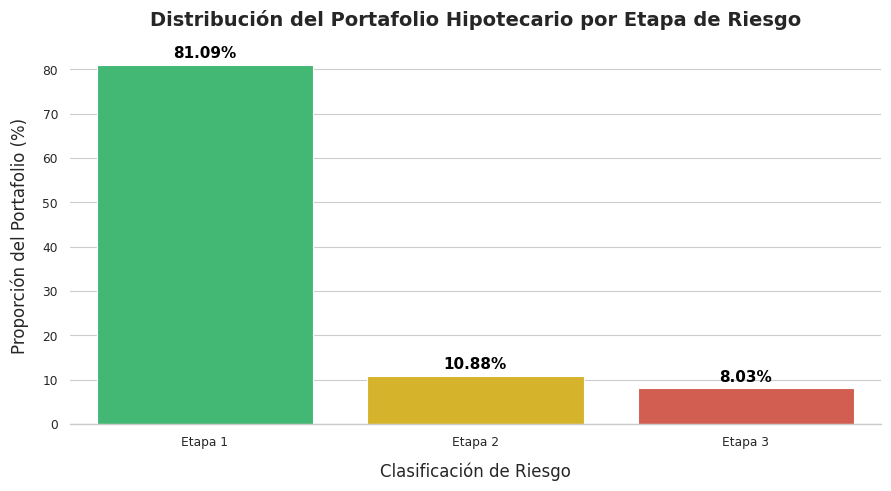

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (ETAPA DE RIESGO)")
print("=" * 60)

# 1. Cálculo de frecuencias y porcentajes
conteo_etapas = df_muestra['etapa'].value_counts()
porcentaje_etapas = df_muestra['etapa'].value_counts(normalize=True) * 100

resumen_objetivo = pd.DataFrame({
    'Frecuencia (Cohortes)': conteo_etapas,
    'Porcentaje (%)': porcentaje_etapas
})

display(resumen_objetivo.round(2))

# 2. Visualización del Desbalance de Clases
# Configuramos el estilo estético de las gráficas
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(9, 5))

# Creamos el gráfico de barras
ax = sns.barplot(
    x=porcentaje_etapas.index, 
    y=porcentaje_etapas.values, 
    palette=["#2ecc71", "#f1c40f", "#e74c3c"] # Verde (Sano), Amarillo (Riesgo), Rojo (Default)
)

# Personalización del gráfico
plt.title('Distribución del Portafolio Hipotecario por Etapa de Riesgo', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Clasificación de Riesgo', fontsize=12, labelpad=10)
plt.ylabel('Proporción del Portafolio (%)', fontsize=12, labelpad=10)

# Agregamos las etiquetas de porcentaje sobre cada barra para mayor legibilidad
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=11, color='black', fontweight='bold',
                xytext=(0, 8), textcoords='offset points')

# Ajustamos márgenes y mostramos
sns.despine(left=True)
plt.tight_layout()
plt.show()

**Interpretación**: Los resultados revelan un panorama financiero realista y estadísticamente coherente con el sector bancario mexicano. El 81.09% de los cohortes se encuentra en Etapa 1, indicando que la gran mayoría de la cartera está sana y al corriente. Por otro lado, tenemos un 10.88% en Etapa 2 (créditos que han comenzado a mostrar signos de deterioro) y un 8.03% en Etapa 3 (cartera vencida).

**Implicaciones para el modelado**:
* Métricas que no se deben priorizar: Existe un desbalance de clases moderado. Esto significa que no podremos utilizar la métrica de ***Accuracy*** para evaluar nuestro modelo supervisado. Un modelo "tonto" que siempre prediga "Etapa 1" obtendría un 81% de exactitud, pero sería desastroso para el banco.
* Métricas a priorizar: Lo adecuado será maximizar el ***Recall*** (Sensibilidad) de las Etapas 2 y 3. Para el negocio, el costo de un Falso Negativo (clasificar un crédito malo como sano y perder el dinero) es enormemente mayor que el costo de un Falso Positivo (clasificar un crédito sano como riesgoso y pedirle más garantías al cliente).

## 4.2. Análisis sobre las variables continuas: Métricas financieras
Una vez entendido el riesgo, procedemos a analizar las dimensiones monetaria de los créditos. Analizaremos cuatro variables continuas fundamentales:
* `monto_originacion_credito`: El préstamo inicial.
* `valor_vivienda_originacion`: El valor del inmueble en garantía.
* `saldo_insoluto_final_periodo`: La deuda actual del cohorte.
* `'tasa_interes_por_saldo_insoluto_final_periodo`: 
* `tasa_ponderada`: El costo del dinero (en porcentaje).

En los datos financieros (especialmente en carteras inmobiliarias e ingresos), las distribuciones rara vez siguen una campana de Gauss. Suelen estar fuertemente sesgadas hacia la derecha, ya que existe un límite inferior (no hay créditos menores a cero), pero no hay un límite superior teórico (existen proyectos o inversiones de miles de millones de pesos).

Generaremos las estadísticas descriptivas de estas variables y sus histogramas para observar la forma de estas distribuciones y confirmar la presencia de valores atípicos extremos de forma visual.

ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMERICAS


,monto_originacion_credito,valor_vivienda_originacion,saldo_insoluto_final_periodo,tasa_ponderada
count,1.000000e+06,1.000000e+06,1.000000e+06,1000000.00
mean,7.339643e+06,1.157621e+07,5.829779e+06,10.31
std,3.539179e+07,5.504006e+07,2.834343e+07,1.91
min,9.883000e+01,9.883000e+01,0.000000e+00,0.00
25%,6.503900e+05,1.145000e+06,4.153187e+05,9.50
50%,1.577797e+06,2.636000e+06,1.162394e+06,10.17
75%,4.200000e+06,6.999000e+06,3.315309e+06,11.00
max,3.151734e+09,9.644387e+09,2.506602e+09,36.00


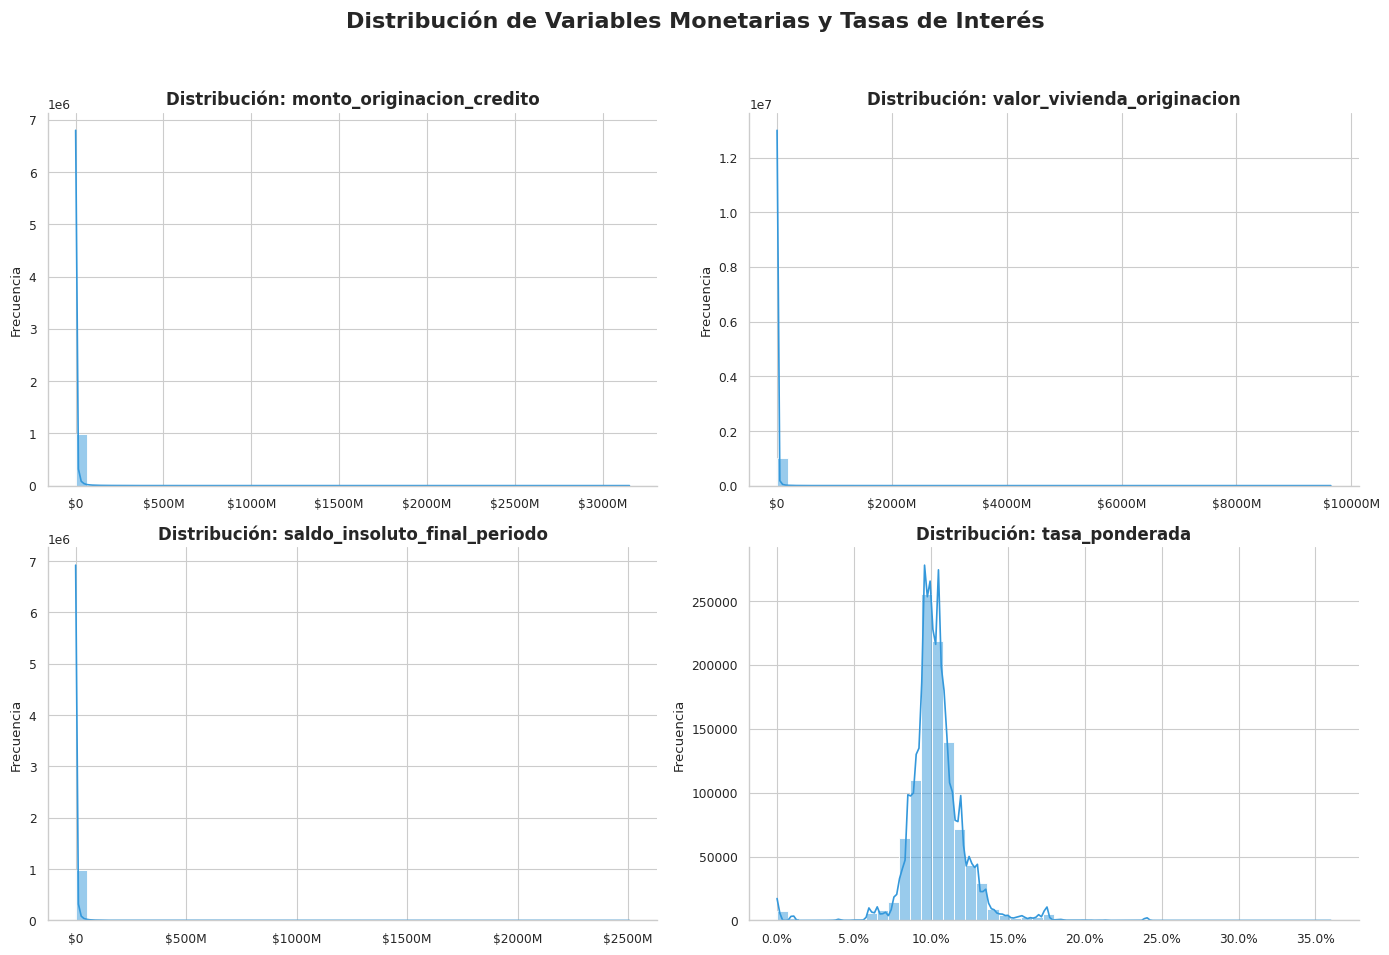

In [7]:
import matplotlib.ticker as ticker

print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMERICAS")
print("=" * 60)

# 1. Definimos las variables de interés
vars_financieras = [
    'monto_originacion_credito', 
    'valor_vivienda_originacion', 
    'saldo_insoluto_final_periodo', 
    'tasa_ponderada'
]

# Mostramos un resumen estadístico (desactivando la notación científica)
resumen_stats = df_muestra[vars_financieras].describe().round(2)
display(resumen_stats)

# Formatter para variables monetarias
def formato_millones(x, pos):
    if x == 0:
        return "$0"
    return f"${x / 1_000_000:.1f}M".replace(".0M", "M")

# Formatter para tasa de interés
def formato_porcentaje(x, pos):
    return f"{x:.1f}%"


# 2. Visualización: Cuadrícula de Histogramas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Monetarias y Tasas de Interés', fontsize=16, fontweight='bold')

# Aplanamos los ejes para iterar fácilmente
axes = axes.flatten()

for i, col in enumerate(vars_financieras):
    # Usamos kde=True para ver la curva de densidad
    # En 1 millón de registros, reducimos los bins para mayor velocidad
    sns.histplot(df_muestra[col], bins=50, kde=True, ax=axes[i], color='#3498db')
    
    axes[i].set_title(f'Distribución: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    
    # Formatear el eje X con comas para millones (excepto en la tasa de interés)
    if col != 'tasa_ponderada':
        axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(formato_millones))
    else:
        axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(formato_porcentaje))

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que no choque con el título principal
sns.despine()
plt.show()

**Interpretación**: 
* La tabla de estadísticas descriptivas y los histogramas revelan una enorme asimetría positiva (Right Skewness) en todas las variables monetarias (monto, valor saldo). Por ejemplo, si observamos el `monto_originacion_credito`, el 75% de los cohortes tienen un préstamo acumulado igual o inferior a $4.2 millones MXN. Sin embargo, el valor máximo registrado alcanza la descomunal cifra de $3,151 millones MXN. Estas gigantescas brechas indican la presencia de valores atípicos (Outliers) extremos, que en el contexto bancario representan desarrollos inmobiliarios masivos o cohortes con miles de créditos agregados en una sola fila. Visualmente, estos outliers obligan a comprimir el 99% de la distribución en la extrema izquierda del gráfico, ocultando su verdadera forma.
* La variable `tasa_ponderada`, al ser porcentual, es la única que mantiene una estructura interpretable en escala lineal, mostrando una media de 10.31%, con una dispersión razonable y casos atípicos puntuales que llegan al 36% (posiblemente créditos de muy alto riesgo).

Entonces para develar la estructura subyacente de las tres primeras variables monetarias, aplicaremos una transformación logarítmica (Base 10) para estabilizar la varianza.

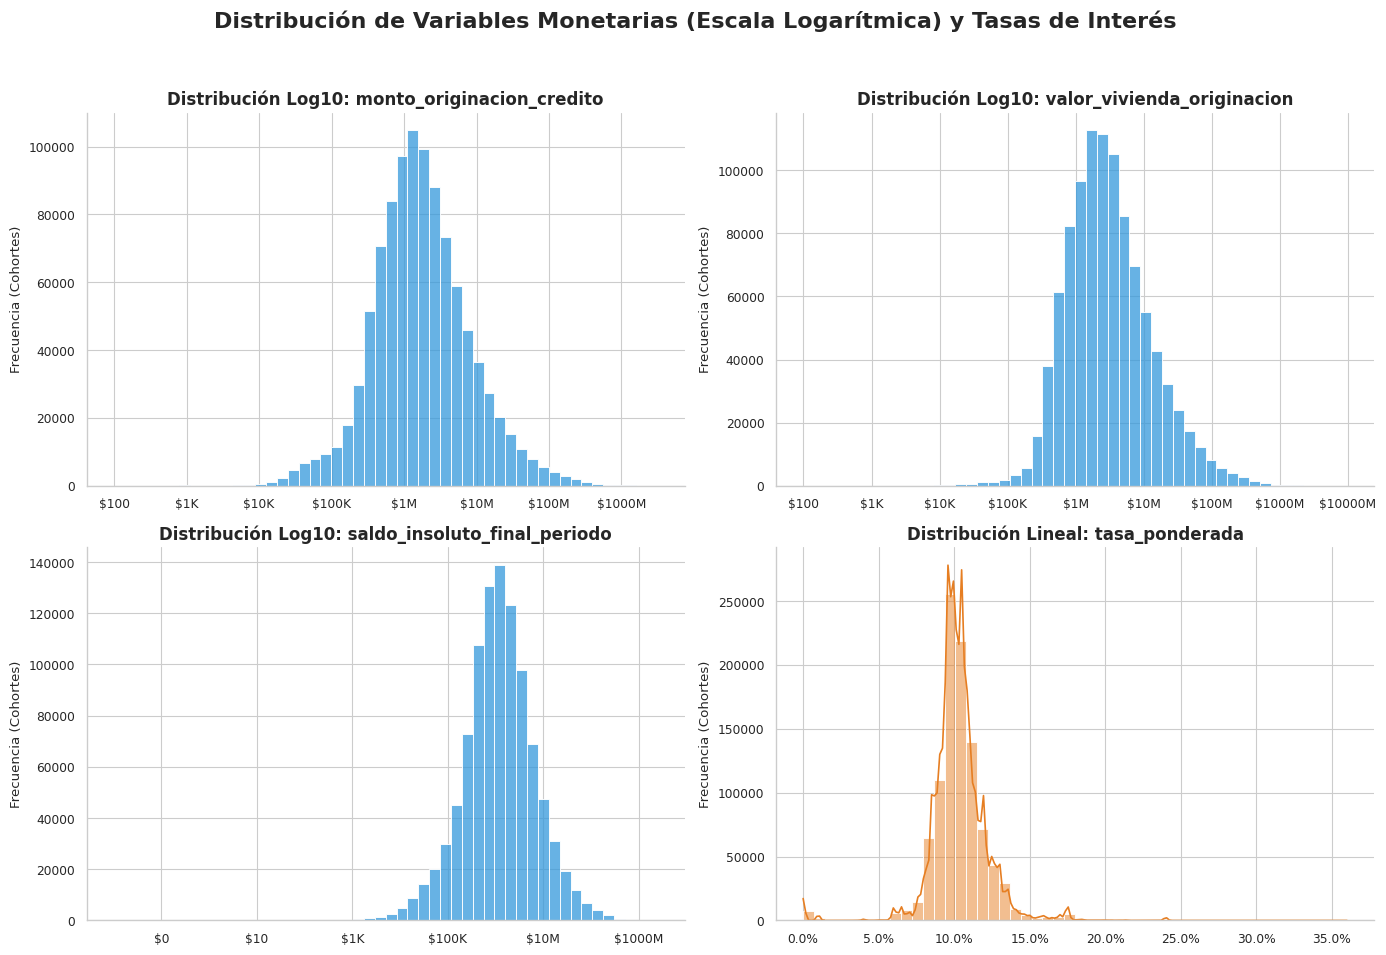

In [8]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Monetarias (Escala Logarítmica) y Tasas de Interés', fontsize=16, fontweight='bold')
axes = axes.flatten()

# Formatter para miles y millones
def formato_pesos_compacto(x, pos):
    if x == 0:
        return "$0"
    elif abs(x) >= 1_000_000:
        valor = x / 1_000_000
        return f"${valor:.1f}M".replace(".0M", "M")
    elif abs(x) >= 1_000:
        valor = x / 1_000
        return f"${valor:.1f}K".replace(".0K", "K")
    else:
        return f"${x:,.0f}"

for i, col in enumerate(vars_financieras):
    ax = axes[i]
    
    # Tratamiento especial: Evitamos el logaritmo de cero sumando 1 (log1p) o filtrando
    # Filtramos valores mayores a cero solo para la gráfica logarítmica para evitar errores matemáticos
    datos_grafica = df_muestra[df_muestra[col] > 0][col]
    
    if col != 'tasa_ponderada':
        # Aplicamos escala logarítmica al eje X para las variables monetarias
        sns.histplot(datos_grafica, bins=50, ax=ax, color='#3498db', log_scale=True)
        ax.set_title(f'Distribución Log10: {col}', fontsize=12, fontweight='bold')
        
        # Formateamos el eje X para que muestre el valor en pesos legibles, no en exponentes
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(formato_pesos_compacto))
    else:
        # La tasa de interés se queda en escala lineal normal
        sns.histplot(df_muestra[col], bins=50, kde=True, ax=ax, color='#e67e22')
        ax.set_title(f'Distribución Lineal: {col}', fontsize=12, fontweight='bold')
        ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100))

    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia (Cohortes)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
sns.despine()
plt.show()

## 4.3. Análisis sobre las variables catégoricas (Perfil demográfico y socioeconómico)
Para completar las estadísticas de nuestra muestra, es esencial analizar la distribución de las variables cualitativas. Esto nos permitirá perfilar a los acreditados comunes del mercado hipotecario mexicano. Analizaremos cuatro dimensiones clave:
* `genero`: Identidad grupal
* `intervalo_edades`: Madurez financiera
* `tipo_acreditado`: Estabilidad laboral
* `sector_laboral`: Agrupación laboral
* `intervalo_ingreso_acreditado`: Ingresos económicos
Estas cinco variables responden exploran **quién** (qué coherte) está pidiendo el crédito.

A continuación veremos sus distribuciones mediante gráficos de frecuencia para identificar las categorías mayoritarias. Esto nos ayudará a entender si el portafolio bancario está concentrado en sectores específicos y posteriormente, cruzar estas características contra el nivel de riesgo en el EDA bivariado.


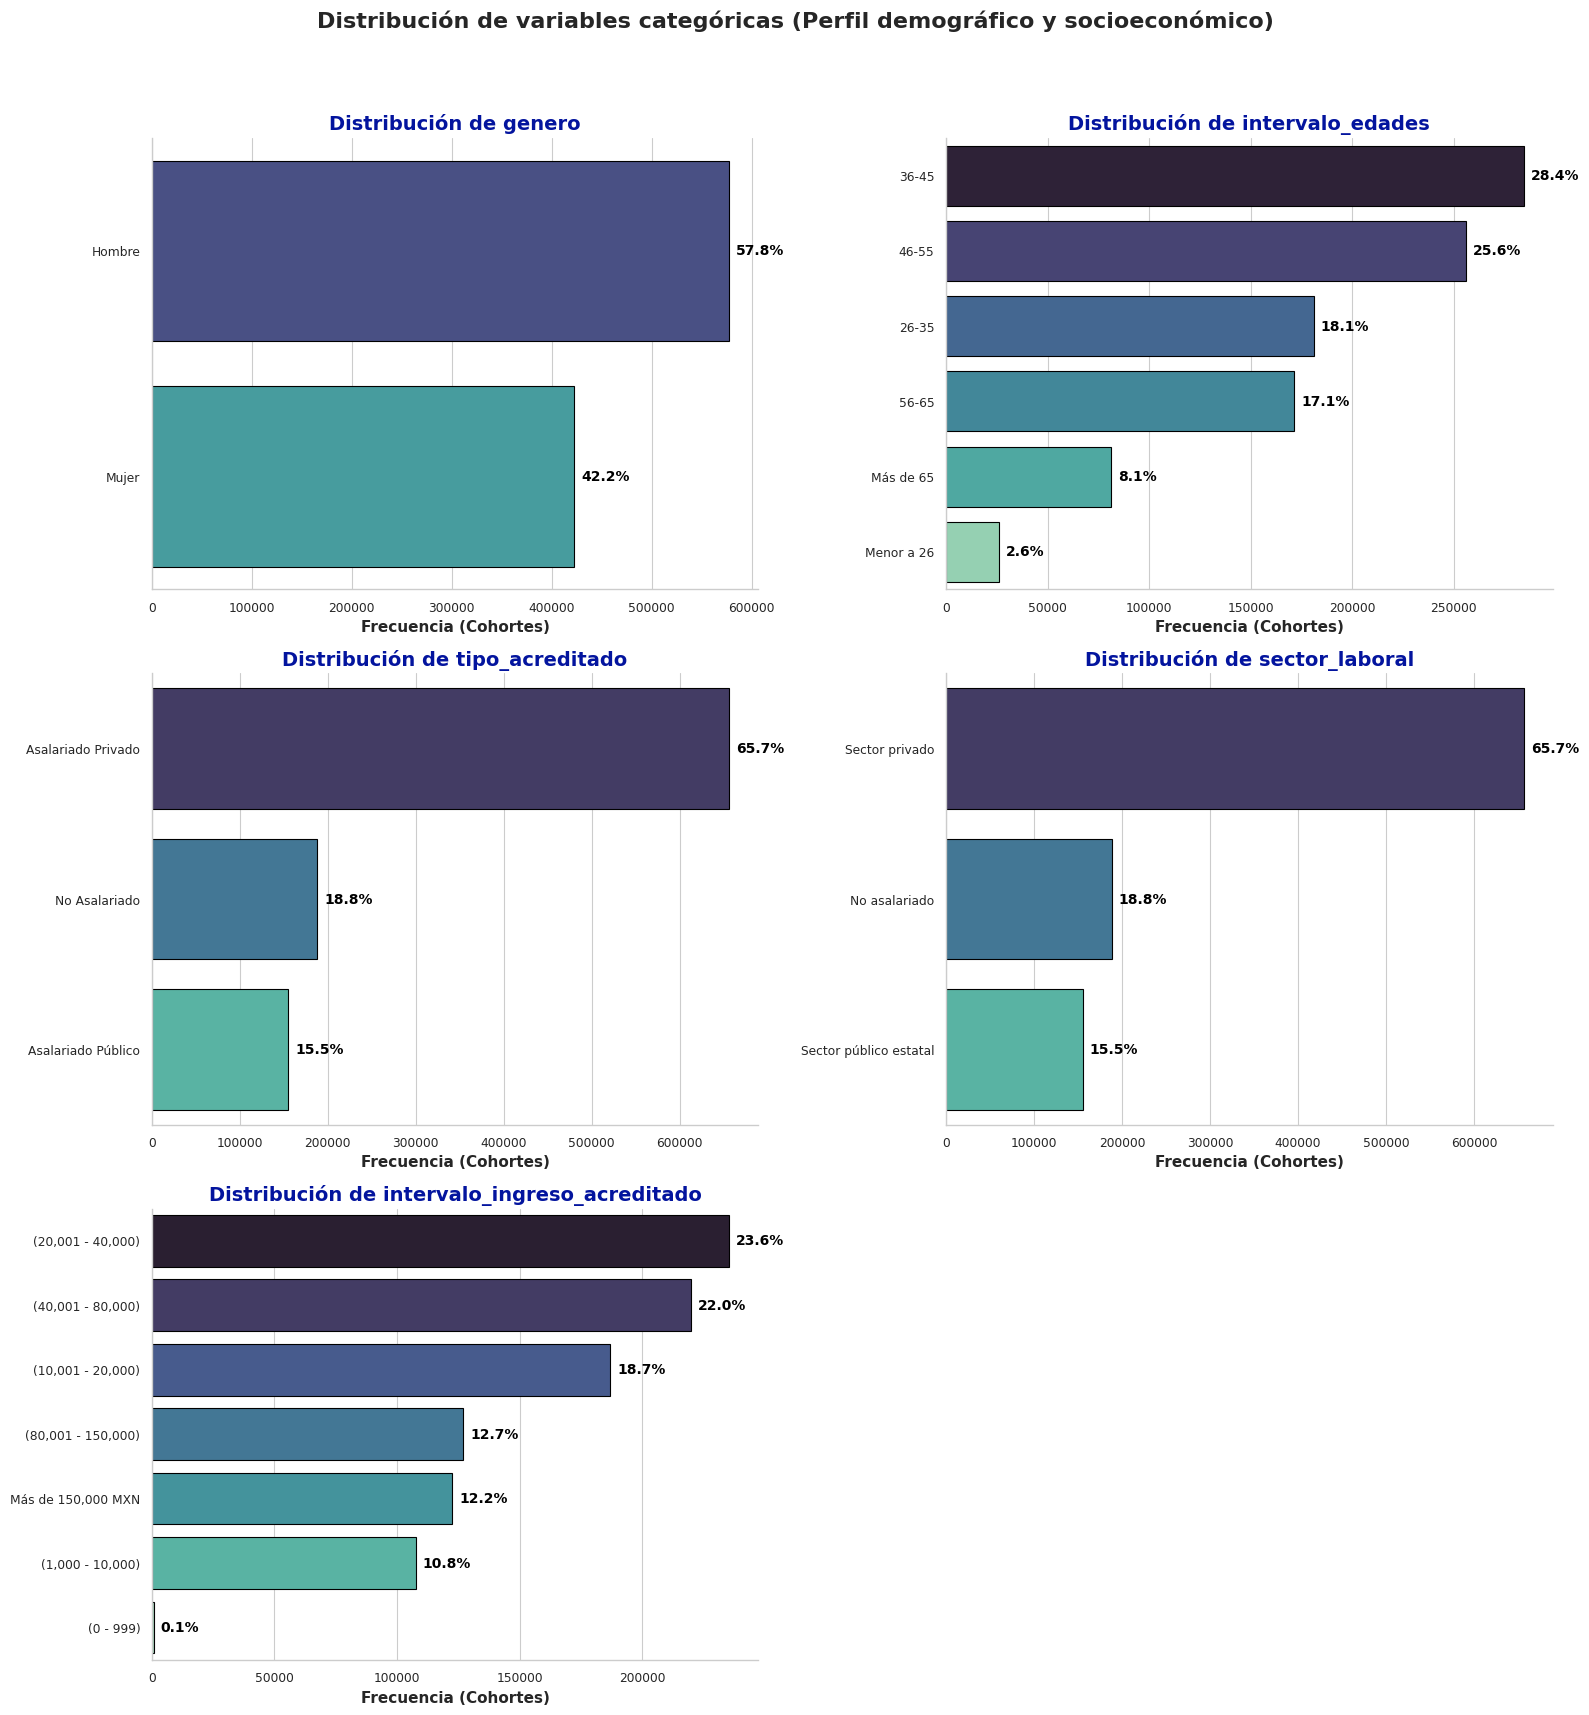

In [9]:
# Definimos las variables categóricas de mayor interés
variables_categoricas = [
    'genero',
    'intervalo_edades',
    'tipo_acreditado',
    'sector_laboral',
    'intervalo_ingreso_acreditado'
]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Distribución de variables categóricas (Perfil demográfico y socioeconómico)', fontsize=16, fontweight='bold')

# Aplanamos el arreglo de ejes para iterarlo fácilmente
axes = axes.flatten()

for i, col in enumerate(variables_categoricas):
    # Obtenemos el orden de las categorías de mayor a menor frecuencia
    orden_frecuencia = df_muestra[col].value_counts().index
    
    # Usamos un gráfico de barras horizontales (y=col) para facilitar la lectura del texto
    ax = sns.countplot(
        y=col, 
        data=df_muestra, 
        order=orden_frecuencia, 
        palette="mako", 
        ax=axes[i],
        edgecolor='black'
    )
    
    axes[i].set_title(f'Distribución de {col}', fontsize=14, fontweight='bold', color='#03149E')
    axes[i].set_xlabel('Frecuencia (Cohortes)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')
    
    # Agregar etiquetas con el porcentaje exacto al final de cada barra
    total = len(df_muestra[col].dropna())
    for p in ax.patches:
        porcentaje = f'{100 * p.get_width() / total:.1f}%'
        ax.annotate(porcentaje, 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    fontsize=10, color='black', fontweight='bold', 
                    xytext=(5, 0), textcoords='offset points')

# Ocultar el sexto plano vacío
axes[-1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
sns.despine()
plt.show()

**Interpretación**: Las gráficas revelan el comportamiento real del mercado hipotecario mexicano y la concentración del portafolio en un nicho poblacional específico:
* Género: La cartera está predominada por hombres, aunque es valioso notar que la mujer no tiene una diferencia abismal. También notemos que aunque nuestro catálogo existe "No binario", no hay suficientes individuos para formar un solo coherte en las millones de observaciones.
* Intervalo de edades: Notamos que la mayor concentración ocurre en la población de mediana edad, concentrándose fuertemente en los intervalos de edad de 36 a 45 años y 46 a 55 años.
* Ingresos económicos: Los ingresos reportados muestran que la cartera atiende predominantemente a la clase media y media-alta, con los rangos de (20,001 - 40,000 MXN) y (40,001 - 80,000 MXN) liderando la distribución.
* Tipo acreditado y Sector Laboral: Una marcada y enorme mayoría de los créditos están asignados al Asalariado/Sector Privados, dejando una participación marginal a los empleados públicos y a la economía informal (No Asalariados). Debido al mismo signficado y proporción de categorías en ambas variables, es casi seguro que estén dando la misma información, siendo candidatas a unificarse en una sola variable posteriormente para reducir la dimensionalidad.

## 4.4. Análisis sobre las variables categóricas: Inmueble y producto comercial

Tras entender "quién" pide el crédito, el siguiente paso es analizar el objeto físico y contractual que respalda la operación. El portafolio hipotecario varía drásticamente dependiendo de la finalidad del préstamo, el valor subyacente de la garantía y la región del país donde se emite.Analizaremos cuatro dimensiones clave correspondientes a la estructura de la vivienda y la estrategia de originación:
* `estado`: Localización del inmueble
* `destino_credito`: Finalidad del préstamo
* `segmento_vivienda`: Clasificación comercial
* `clave_producto_hipotecario`: El nivel de fragmentación en la oferta comercial de los bancos.



PERFIL DEL INMUEBLE Y PRODUCTO COMERCIAL
 -> Alta Cardinalidad: Existen 471 productos hipotecarios distintos.
 -> Concentración: Los 5 productos principales abarcan el 21.95% de la muestra total.



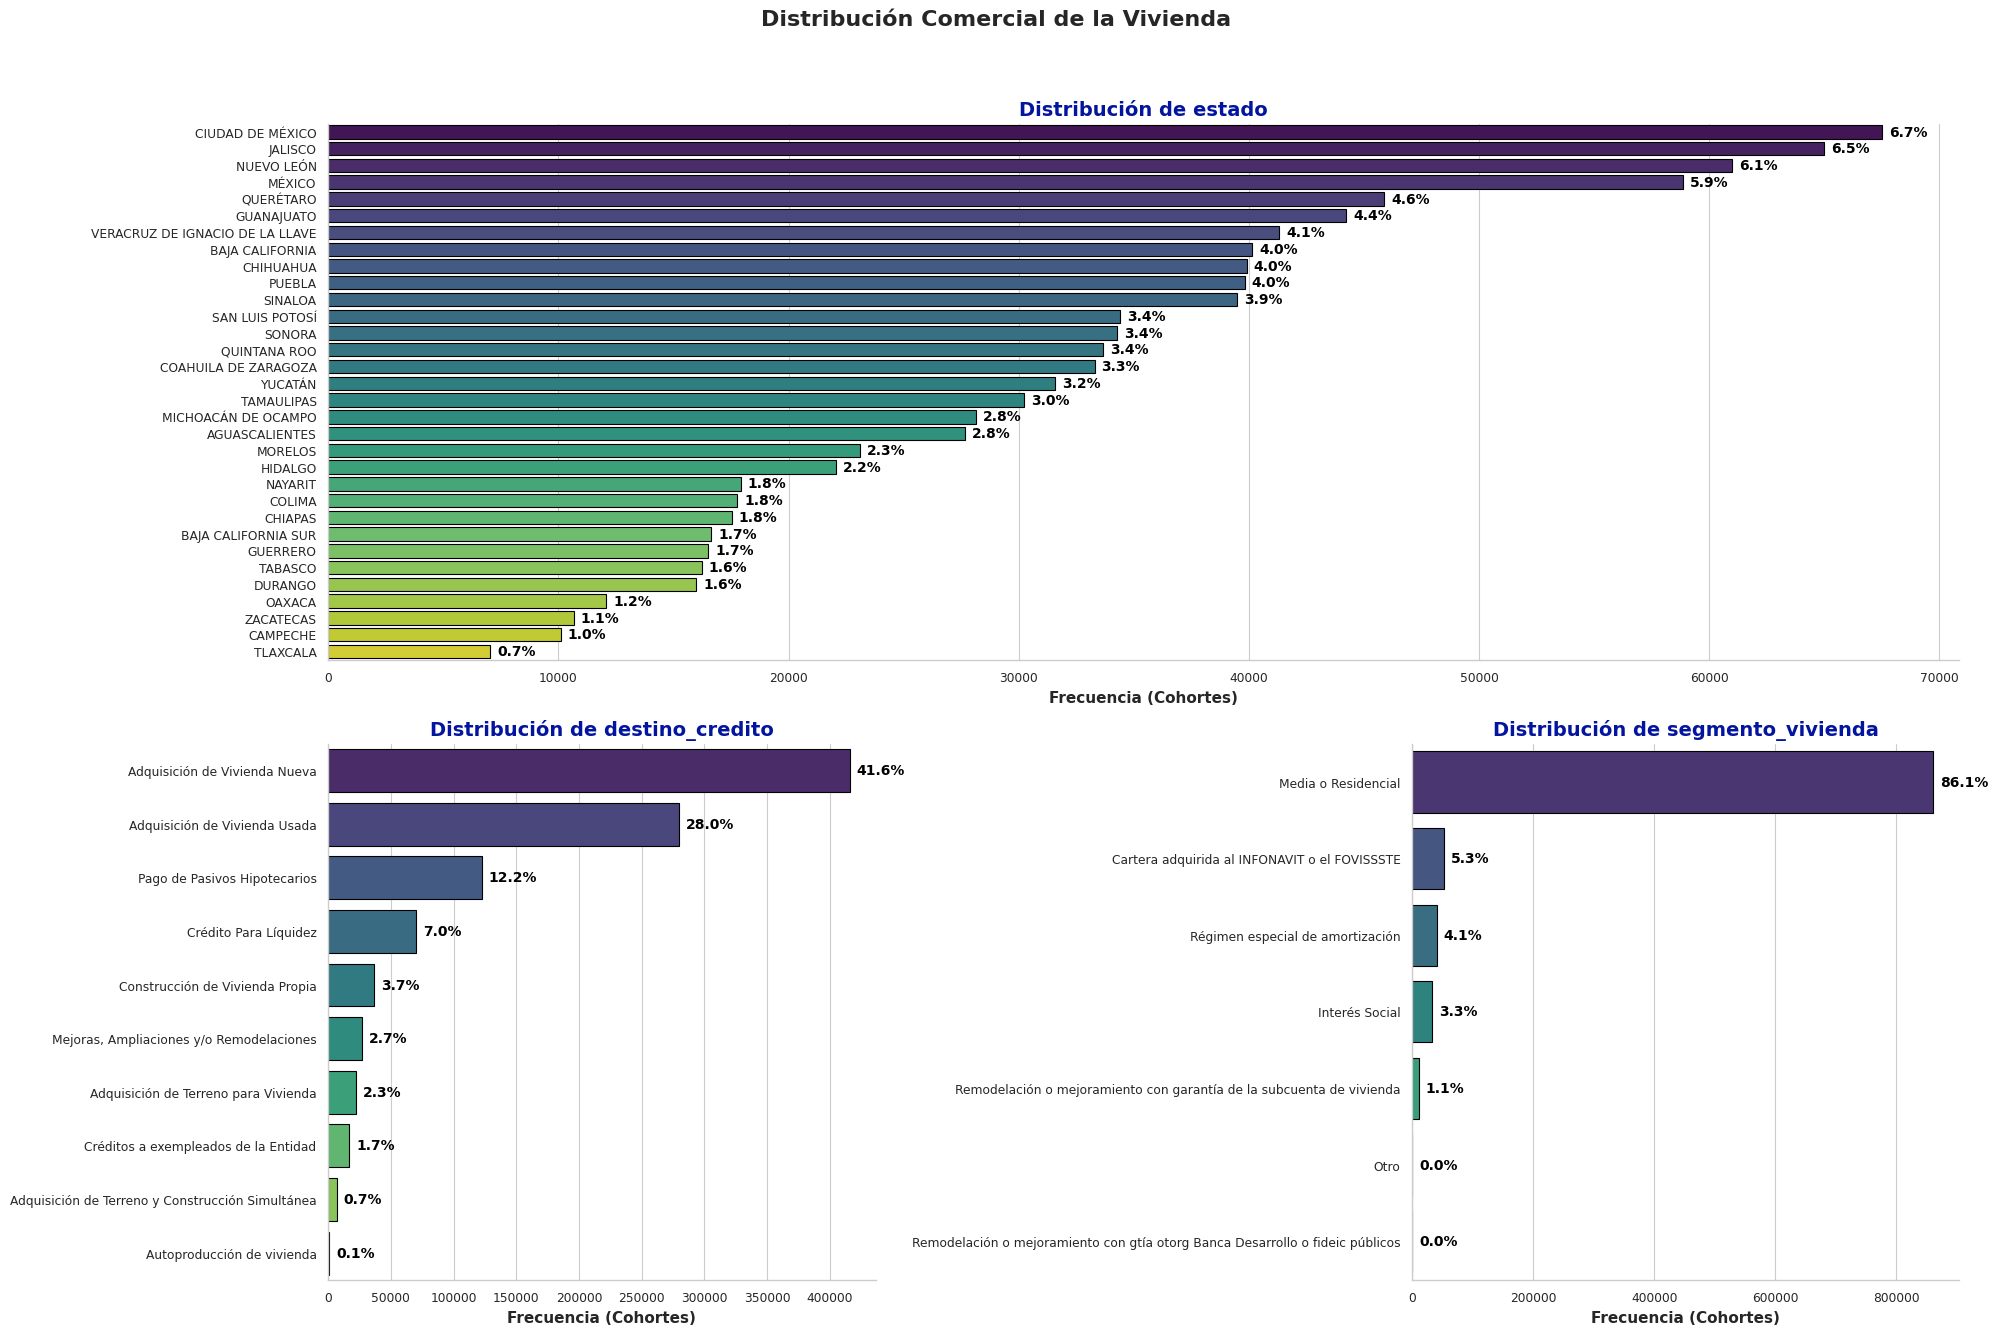

In [10]:
print("=" * 60)
print("PERFIL DEL INMUEBLE Y PRODUCTO COMERCIAL")
print("=" * 60)

# 1. Análisis de alta cardinalidad (Producto Hipotecario)
conteo_productos = df_muestra['clave_producto_hipotecario'].nunique()
top_5_productos = df_muestra['clave_producto_hipotecario'].value_counts().head(5)
porcentaje_top_5 = (top_5_productos.sum() / len(df_muestra)) * 100

print(f" -> Alta Cardinalidad: Existen {conteo_productos:,} productos hipotecarios distintos.")
print(f" -> Concentración: Los 5 productos principales abarcan el {porcentaje_top_5:.2f}% de la muestra total.\n")


# 2. Variables para visualización de frecuencias
vars_inmueble = ['estado', 'destino_credito', 'segmento_vivienda']

# Ajustamos la figura para 3 gráficos: el estado ocupará toda la fila superior por tener 32 barras
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Distribución Comercial de la Vivienda', fontsize=16, fontweight='bold')

# Grid especificado: 1 fila grande (estado), 1 fila dividida en 2 (destino y segmento)
gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, :]) # Ocupa las dos columnas de la primera fila
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
axes_inmueble = [ax1, ax2, ax3]

for i, col in enumerate(vars_inmueble):
    ax = axes_inmueble[i]
    orden_frecuencia = df_muestra[col].value_counts().index
    
    # En el caso del Estado (32 valores), hacemos las barras más delgadas para que no se encimen
    sns.countplot(
        y=col, 
        data=df_muestra, 
        order=orden_frecuencia, 
        palette="viridis", 
        ax=ax,
        edgecolor='black'
    )
    
    ax.set_title(f'Distribución de {col}', fontsize=14, fontweight='bold', color='#03149E')
    ax.set_xlabel('Frecuencia (Cohortes)', fontsize=11, fontweight='bold')
    ax.set_ylabel('')
    
    total = len(df_muestra[col].dropna())
    for p in ax.patches:
        porcentaje = f'{100 * p.get_width() / total:.1f}%'
        ax.annotate(porcentaje, 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    fontsize=10, color='black', fontweight='bold', 
                    xytext=(5, 0), textcoords='offset points')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
sns.despine()
plt.show()

**Interpretación**: El análisis de las características del inmueble y el producto revela las dinámicas estructurales del mercado hipotecario:
* Estado: Existe una clara centralización del crédito hipotecario en los mayores regiones económicas e industriales del país: Ciudad de México (6.7%), Jalisco (7.5%) y Nuevo León (6.1%).
* Destino de crédito: El mercado está fuertemente inclinado hacia la Adquisición de Vivienda, en particular vivienda nueva (41.6%) por encima de la vivienda usada (28.0%). 
* Segmento de vivienda: Tenemos una gigante predonminancia (86.1%) de la cartera concentrandose en el segmento Media o Residencial, dejando demasiado resagados a otros segmentos.
* Producto Hipotecario: La altísima cardinalidad (471 productos distintos) y baja concentración (el top 5 apenas suma el 21.95%) nos confirma que el nombre comercial del crédito está demasiado fragmentado para ser un predictor útil generalizable, validando por ahora, la decisión de no priorizar su exploración gráfica.

## 4.5. Análisis sobre las variables categóricas: Temporalidad e Instituciones
Para concluir el análisis univariado, revisaremos las variables que contextualizan el "cuándo" y el "quién otorga el cŕedito": periodo, sector, institucion y la moneda de originación.
Dado el perfil de estas variables, no generaremos gráficos de barras exhaustivos, basándonos en las siguientes justificaciones metodológicas:
* `periodo`: Es una variable temporal. En el dominio del riesgo, el tiempo suele analizarse mediante gráficos de series de tiempo para evaluar la evolución histórica de la cartera vencida, no como conteos estáticos.
* `sector` e `institucion`: Buscaremos verificar su concentración estadística para confirmar si el análisis está sesgado hacia un nicho bancario particular (Banca Múltiple) o hacia un grupo reducido de bancos líderes.
* `moneda`: Observaremos estadísticamente la hegemonía del Peso Mexicano frente a otros esquemas como UDIS o VSMG.

A continuación, las métricas de concentración de estas variables para integrarlas a nuestra radiografía general antes de proceder al Análisis Bivariado.

In [11]:
print("=" * 60)
print("ESTADÍSTICAS DE TEMPORALIDAD, INSTITUCIONES Y DIVISAS")
print("=" * 60)

variables_contexto = ['periodo', 'sector', 'institucion', 'moneda']

for col in variables_contexto:
    print(f"\n--- Variable: {col.upper()} ---")
    
    # Calculamos frecuencias y porcentajes
    conteo = df_muestra[col].value_counts()
    porcentaje = df_muestra[col].value_counts(normalize=True) * 100
    
    # Combinamos en un DataFrame
    resumen = pd.DataFrame({
        'Frecuencia': conteo,
        'Porcentaje (%)': porcentaje
    })
    
    # Si hay muchos valores (como periodo o institucion), mostramos solo el Top 5
    if len(resumen) > 5:
        print(f"Total de categorías únicas: {len(resumen)}. Mostrando el Top 5 de mayor volumen:")
        display(resumen.head(5).round(2))
    else:
        display(resumen.round(2))

ESTADÍSTICAS DE TEMPORALIDAD, INSTITUCIONES Y DIVISAS

--- Variable: PERIODO ---
Total de categorías únicas: 25. Mostrando el Top 5 de mayor volumen:


,Frecuencia,Porcentaje (%)
periodo,,
202504,40676,4.07
202411,40555,4.06
202502,40290,4.03
202508,40261,4.03
202506,40209,4.02



--- Variable: SECTOR ---


,Frecuencia,Porcentaje (%)
sector,,
Banca Múltiple,974696,97.47
Banca de Desarrollo,16199,1.62
SOFOMER,9105,0.91



--- Variable: INSTITUCION ---
Total de categorías únicas: 32. Mostrando el Top 5 de mayor volumen:


,Frecuencia,Porcentaje (%)
institucion,,
Santander,313014,31.30
Banorte,187162,18.72
BBVA México,155475,15.55
Scotiabank,76672,7.67
HSBC,75329,7.53



--- Variable: MONEDA ---


,Frecuencia,Porcentaje (%)
moneda,,
Moneda Nacional (Pesos),978237,97.82
UDIS,16303,1.63
VSMG (Veces Salario Mínimo General),5131,0.51
Dólares de E.E.U.U.A.,329,0.03


**Interpretación**
* Periodo: La distribución es uniforme (~4% de los registros por cada mes del top 5). Esto nos indica que el portafolio no está sesgado estacionalmente ni concentrado en un solo trimestre, ofreciendo una ventana histórica estable a lo largo de los 25 meses de reporte.
* Sector: Se hace evidente una concentración masiva del mercado en la Banca Múltiple (97.47%), dejando a la Banca de Desarrollo y SOFOMERES como actores de nicho. 
* Institución: Estos cinco bancos (Santander, Banorte, BBVA, Scotiabank y HSBC) acaparan más del 80% de los cohortes hipotecarios del país, lo cual dicta que las políticas de riesgo de estas cinco instituciones moldean el mercado nacional.
* Divisas: El Peso Mexicano domina casi por completo (97.82%). No obstante, el 2.14% correspondiente a UDIS y VSMG representa más de 21,000 cohortes de crédito. Esta masa crítica es estadísticamente suficiente para evaluar su impacto en el deterioro de la cartera durante el análisis multivariado.

# 5. Análisis Exploratorio de Datos Bivariado

Tras comprender la distribución individual de nuestras variables, el siguiente paso es explorar las relaciones intrínsecas entre ellas. No exploraremos todas las combinaciones, sino que identificaremos conjuntos de variables y analizaremos la correlación oculta y, lo más importante, el impacto de cada característica sobre nuestra variable objetivo (etapa).

## 5.1. Correlación de las variables continuas
En los modelos de aprendizaje, especialmente en los supervisados, introducir variables altamente correlacionadas entre sí genera inestabilidad en los coeficientes y aumenta innecesariamente la complejidad computacional.
Para evaluar esto, calcularemos una Matriz de Correlación (coeficiente de Pearson) exclusivamente sobre nuestras variables continuas monetarias. Buscamos identificar si estas variables poseen una relación lineal tan fuerte que nos permita descartar alguna en la posterior fase de Reducción de Datos.


MATRIZ DE CORRELACIÓN DE VARIABLES CONTINUAS


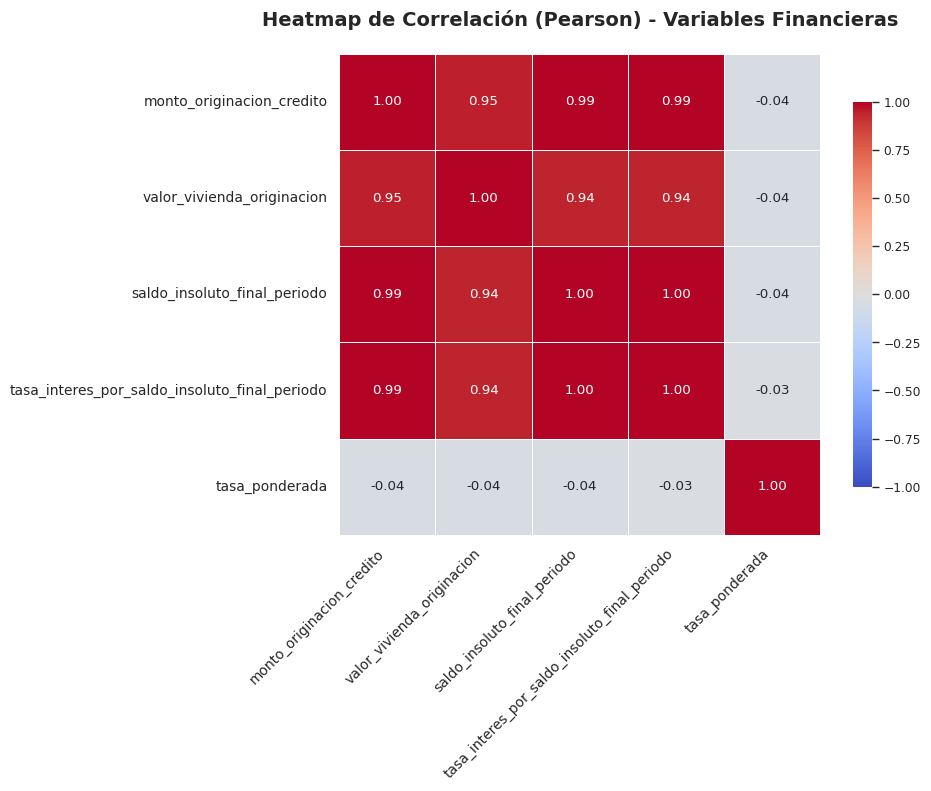

Pares con ALTA correlación lineal detectada (|r| > 0.80):
 -> monto_originacion_credito vs valor_vivienda_originacion: 0.949
 -> monto_originacion_credito vs saldo_insoluto_final_periodo: 0.993
 -> monto_originacion_credito vs tasa_interes_por_saldo_insoluto_final_periodo: 0.992
 -> valor_vivienda_originacion vs saldo_insoluto_final_periodo: 0.945
 -> valor_vivienda_originacion vs tasa_interes_por_saldo_insoluto_final_periodo: 0.943
 -> saldo_insoluto_final_periodo vs tasa_interes_por_saldo_insoluto_final_periodo: 0.999


In [12]:
print("=" * 60)
print("MATRIZ DE CORRELACIÓN DE VARIABLES CONTINUAS")
print("=" * 60)

# Seleccionamos estrictamente las variables numéricas continuas
variables_correlacion = [
    'monto_originacion_credito', 
    'valor_vivienda_originacion', 
    'saldo_insoluto_final_periodo',
    'tasa_interes_por_saldo_insoluto_final_periodo',
    'tasa_ponderada'
]

# Calculamos la matriz de correlación de Pearson
matriz_corr = df_muestra[variables_correlacion].corr()

# Generamos la visualización (Heatmap)
plt.figure(figsize=(10, 8))

# Usamos una paleta divergente (coolwarm) donde rojo es correlación positiva fuerte
sns.heatmap(
    matriz_corr, 
    annot=True,          # Mostrar los números dentro de las celdas
    fmt=".2f",           # Formato a 2 decimales
    cmap="coolwarm", 
    vmin=-1, vmax=1,     # Límites de la correlación de Pearson
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Heatmap de Correlación (Pearson) - Variables Financieras', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# Imprimimos los pares altamente correlacionados (> 0.80 o < -0.80)
print("Pares con ALTA correlación lineal detectada (|r| > 0.80):")
alta_corr = matriz_corr.unstack()
alta_corr = alta_corr[abs(alta_corr) >= 0.80]
alta_corr = alta_corr[alta_corr < 1.0].drop_duplicates()

if not alta_corr.empty:
    for idx, valor in alta_corr.items():
        print(f" -> {idx[0]} vs {idx[1]}: {valor:.3f}")
else:
    print(" -> No se detectaron colinealidades severas superiores a 0.80.")

**Interpretación**: Los resultados de la matriz confirman un alto grado de colinealidad lineal entre casi todas las variables monetarias. Por ejemplo, la relación entre el saldo insoluto y la tasa de intereses por saldo insoluto alcanza un coeficiente de 0.999. Esto es matemáticamente lógico, ya que la segunda métrica es una derivación de la primera. Lo mismo ocurre entre el monto de originación del crédito y el valor de la vivienda (0.949), reflejando que están cantidad suelen ser estables y altamente relacionadas. Introducir toda esta información al modelo generaría redundancia. Por lo tanto, en la futura etapa de selección de características, será prudente conservar únicamente una métrica de volumen y complementarla con métricas relativas (como la tasa ponderada, la cual demostró ser independiente al no presentar alta correlación con el resto).

VISUALIZACIÓN BIVARIADA: SALDO INSOLUTO VS TASA DE INTERÉS


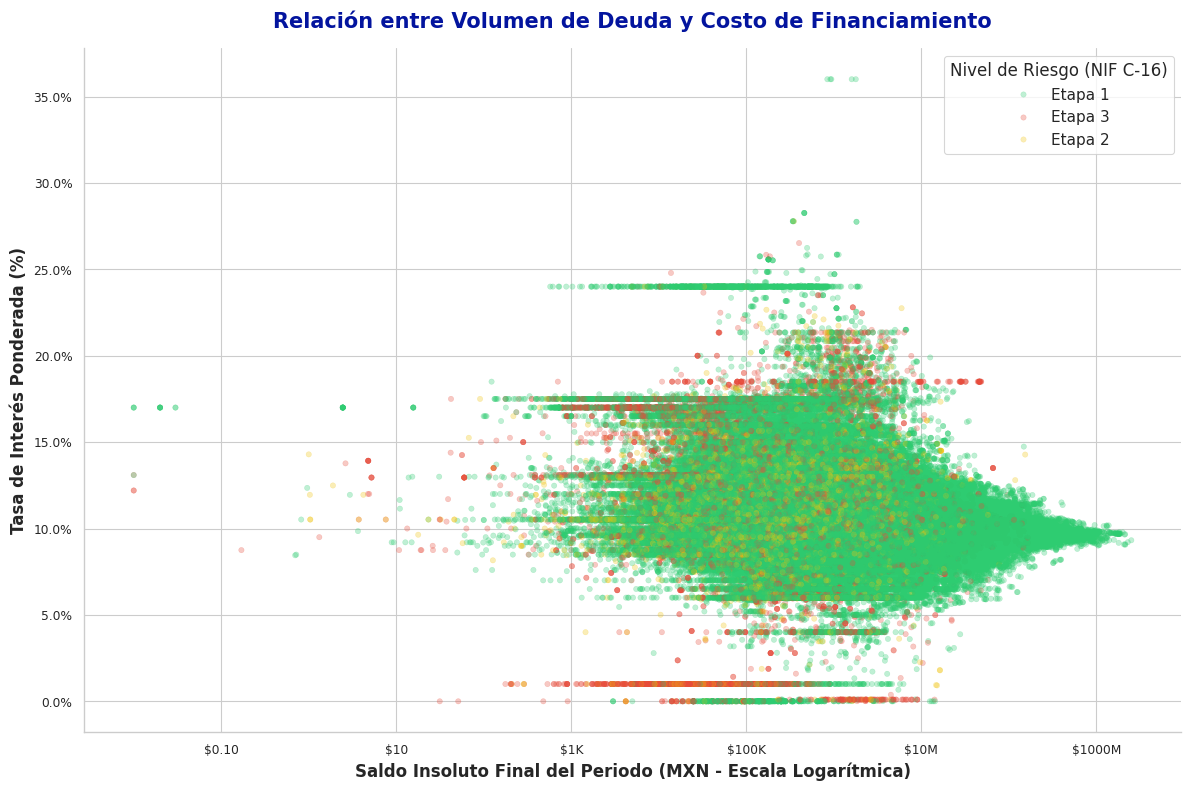

In [13]:
import matplotlib.ticker as ticker

print("=" * 60)
print("VISUALIZACIÓN BIVARIADA: SALDO INSOLUTO VS TASA DE INTERÉS")
print("=" * 60)

# Para la gráfica en escala logarítmica, debemos omitir temporalmente los saldos exactamente en cero
df_grafica = df_muestra[df_muestra['saldo_insoluto_final_periodo'] > 0]

plt.figure(figsize=(12, 8))

# Formatter para escala logaritmica
def formato_pesos_log(x, pos):
    if x < 1:
        return f"${x:.2f}"
    elif x >= 1_000_000:
        return f"${x / 1_000_000:.1f}M".replace(".0M", "M")
    elif x >= 1_000:
        return f"${x / 1_000:.1f}K".replace(".0K", "K")
    else:
        return f"${x:,.0f}"

# Generamos el Scatter Plot
# Utilizamos alpha (transparencia) para mitigar el overplotting debido al millón de registros
ax = sns.scatterplot(
    data=df_grafica,
    x='saldo_insoluto_final_periodo',
    y='tasa_ponderada',
    hue='etapa',
    palette={"Etapa 1": "#2ecc71", "Etapa 2": "#f1c40f", "Etapa 3": "#e74c3c"},
    alpha=0.3,  
    s=15,      # Tamaño de los puntos
    edgecolor=None
)

# Personalización del gráfico
plt.title('Relación entre Volumen de Deuda y Costo de Financiamiento', fontsize=15, fontweight='bold', pad=15, color='#03149E')
plt.xlabel('Saldo Insoluto Final del Periodo (MXN - Escala Logarítmica)', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Interés Ponderada (%)', fontsize=12, fontweight='bold')

# Formato de los ejes (Logarítmico para X, Porcentual para Y)
plt.xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formato_pesos_log))
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=100))

# Ajuste de la leyenda
plt.legend(title='Nivel de Riesgo (NIF C-16)', title_fontsize='12', fontsize='11', loc='upper right', frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

VISUALIZACIÓN BIVARIADA (POR ETAPAS): SALDO VS TASA DE INTERÉS


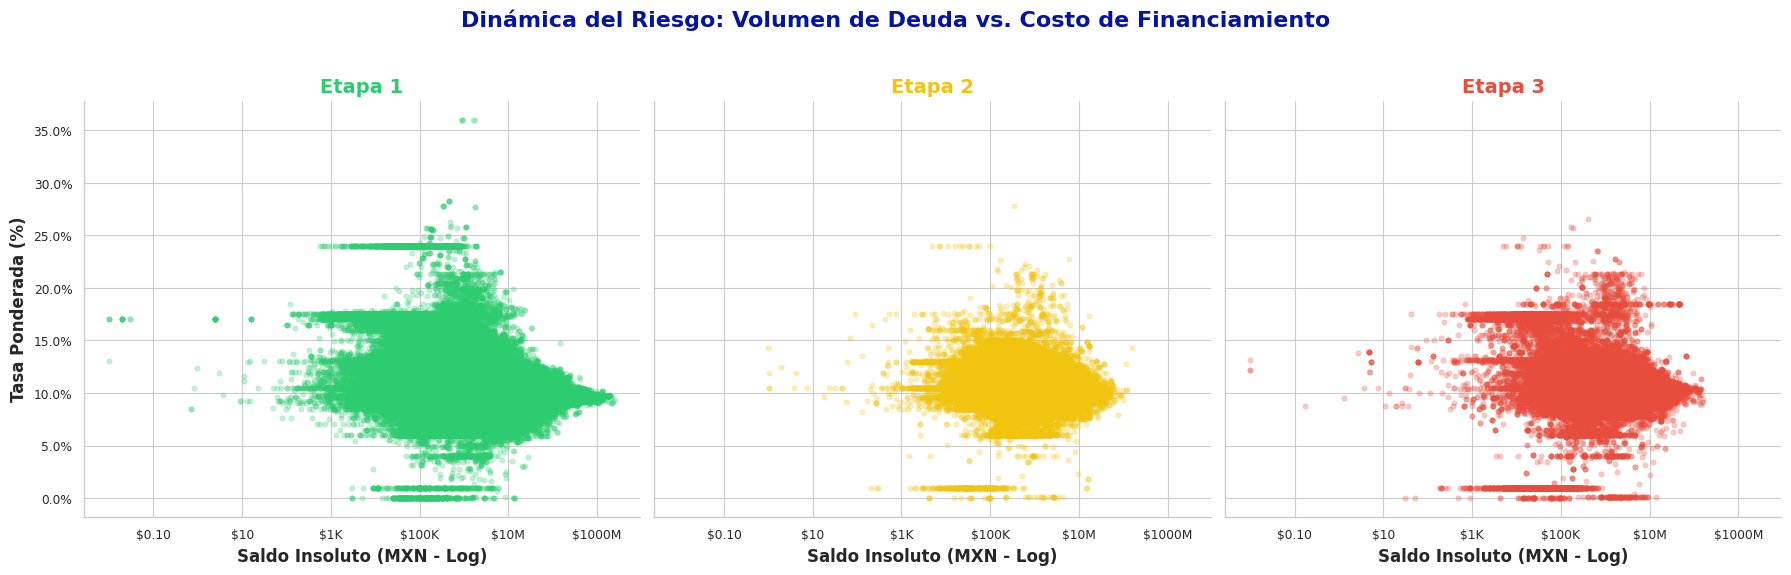

In [14]:
import matplotlib.ticker as ticker

print("=" * 60)
print("VISUALIZACIÓN BIVARIADA (POR ETAPAS): SALDO VS TASA DE INTERÉS")
print("=" * 60)

# Omitimos saldos en cero estrictos para la escala logarítmica
df_grafica = df_muestra[df_muestra['saldo_insoluto_final_periodo'] > 0]

# Creamos una figura con 3 subgráficos compartiendo los mismos ejes para que sean comparables
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
fig.suptitle('Dinámica del Riesgo: Volumen de Deuda vs. Costo de Financiamiento', fontsize=16, fontweight='bold', color='#03149E')

etapas = ['Etapa 1', 'Etapa 2', 'Etapa 3']
paleta_riesgo = {"Etapa 1": "#2ecc71", "Etapa 2": "#f1c40f", "Etapa 3": "#e74c3c"}

for i, etapa in enumerate(etapas):
    ax = axes[i]
    
    # Filtramos los datos correspondientes a la etapa actual
    df_etapa = df_grafica[df_grafica['etapa'] == etapa]
    
    sns.scatterplot(
        data=df_etapa,
        x='saldo_insoluto_final_periodo',
        y='tasa_ponderada',
        color=paleta_riesgo[etapa],
        alpha=0.3,  
        s=15,      
        ax=ax,
        edgecolor=None
    )
    
    ax.set_title(etapa, fontsize=14, fontweight='bold', color=paleta_riesgo[etapa])
    ax.set_xlabel('Saldo Insoluto (MXN - Log)', fontsize=12, fontweight='bold')
    
    # Formato de los ejes
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(formato_pesos_log))
    
    # Solo ponemos la etiqueta del eje Y en el primer gráfico
    if i == 0:
        ax.set_ylabel('Tasa Ponderada (%)', fontsize=12, fontweight='bold')
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=100))
    else:
        ax.set_ylabel('')

sns.despine()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Interpretación**: Al analizar los diagramas de dispersión por etapas de riesgo, podemos observar que:
* En las tres etapas es evidente la formación de "bandas" o líneas horizontales densas. Esto refleja el diseño comercial de los productos bancarios, donde las instituciones ofrecen tasas estandarizadas y cerradas (por ejemplo, 9%, 10%, 11.5%) en lugar de una sola forma continua.
* A diferencia de lo que se podría intuir, las tasas de interés están fuertemente concentradas en el rango del 7% al 15% para todas las etapas. Las formas de estas dispersiones no presentan cambios estructurales drásticos al pasar de la Etapa 1 a la Etapa 3.

Esto nos indica que el incumplimiento no es exclusivo de los créditos más caros o de los montos más altos/bajos; el riesgo de impago está distribuido a lo largo de todo el espectro de tasas comerciales regulares. Visualmente, esto nos dice que el problema no es linealmente separable con dos variables.

## 5.2. Dinámica del Riesgo: Variables Categóricas vs. Variable Objetivo
El siguiente paso es evaluar cómo interactúa el perfil del acreditado con el riesgo de impago, cruzando las dimensiones cualitativas clave contra nuestra variable objetivo ($Y$ = etapa). Para ello introducimos la **Tasa de Deterioro**, que no es más que la probabilidad de incumplimiento condicionada a los diferentes perfiles del portafolio.

**Definición**:  Sea $Y \in \{1, 2, 3\}$ el espacio muestral de las etapas de riesgo NIF C-16, y sea $X$ una variable categórica cualquiera (por ejemplo, el género o la moneda) con un conjunto de categorías $x_i$. Definimos el evento de "Deterioro" ($D$) como la unión de las etapas de riesgo significativo y cartera vencida: $D = \{Y=2 \cup Y=3\}$. La Tasa de Deterioro es la estimación frecuentista de la Probabilidad de Incumplimiento (Probability of Default, PD) dado un perfil específico:
$$
P(D \mid X = x_i) = \frac{\text{Frecuencia}(Y \in \{2,3\} \cap X = x_i)}{\text{Frecuencia}(X = x_i)}
$$

Calcular $P(D \mid X)$ nos permite identificar si una variable es útil para nuestro futuro modelo. Si la probabilidad de deterioro es demasiado similar en todas las categorías de $X$ (ej. hombres y mujeres incumplen exactamente igual), la variable no aporta información discriminante. Si la probabilidad cambia drásticamente, hemos encontrado un fuerte predictor de riesgo.

Para este ejercicio, priorizaremos el cruce con las siguientes dimensiones críticas que, son indicadores natuales de un score de cŕedito, que similarmente, exponen la solvencia y la exposición al riesgo:
* `moneda`
* `intervalo_ingreso_acreditado`
* `sector_laboral`
* `intervalo_edades`
* `segmento_vivienda`
* `destino_credito`



In [15]:
print("=" * 60)
print("PROBABILIDAD CONDICIONAL: TASA DE DETERIORO POR PERFIL")
print("=" * 60)

# Variables predictoras (X) seleccionadas para el análisis condicional
columnas_analisis = [
    'moneda', 
    'intervalo_ingreso_acreditado',
    'sector_laboral',
    'intervalo_edades',
    'segmento_vivienda',
    'destino_credito'
]

for col in columnas_analisis:
    print(f"\n--- Análisis de Riesgo Condicionado a: {col.upper()} ---")
    
    # 1. Calculamos P(Y | X) usando crosstab con normalización por filas (index)
    prob_condicional = pd.crosstab(
        index=df_muestra[col], 
        columns=df_muestra['etapa'], 
        normalize='index' # Normaliza para que la suma de la fila sea 1.0 (100%)
    ) * 100
    
    # 2. Calculamos P(D | X) = P(Y=2 | X) + P(Y=3 | X)
    # Verificamos que las etapas existan para evitar errores de llave
    columnas_etapas = prob_condicional.columns.tolist()
    
    if 'Etapa 2' in columnas_etapas and 'Etapa 3' in columnas_etapas:
        prob_condicional['Tasa_Deterioro_Total (%)'] = prob_condicional['Etapa 2'] + prob_condicional['Etapa 3']
    elif 'Etapa 3' in columnas_etapas:
        prob_condicional['Tasa_Deterioro_Total (%)'] = prob_condicional['Etapa 3']
    else:
        prob_condicional['Tasa_Deterioro_Total (%)'] = 0.0
        
    # 3. Ordenamos de mayor a menor probabilidad de deterioro para destacar los riesgos
    prob_condicional = prob_condicional.sort_values(by='Tasa_Deterioro_Total (%)', ascending=False)
    
    # Formato de visualización a 2 decimales
    display(prob_condicional.round(2))

PROBABILIDAD CONDICIONAL: TASA DE DETERIORO POR PERFIL

--- Análisis de Riesgo Condicionado a: MONEDA ---


etapa,Etapa 1,Etapa 2,Etapa 3,Tasa_Deterioro_Total (%)
moneda,,,,
Dólares de E.E.U.U.A.,57.75,14.89,27.36,42.25
VSMG (Veces Salario Mínimo General),70.63,6.63,22.74,29.37
UDIS,71.82,13.59,14.60,28.18
Moneda Nacional (Pesos),81.31,10.86,7.84,18.69



--- Análisis de Riesgo Condicionado a: INTERVALO_INGRESO_ACREDITADO ---


etapa,Etapa 1,Etapa 2,Etapa 3,Tasa_Deterioro_Total (%)
intervalo_ingreso_acreditado,,,,
"Más de 150,000 MXN",78.79,12.21,9.00,21.21
"(10,001 - 20,000)",79.78,11.11,9.11,20.22
"(1,000 - 10,000)",79.89,10.39,9.72,20.11
"(20,001 - 40,000)",81.27,11.11,7.62,18.73
"(80,001 - 150,000)",82.71,10.43,6.86,17.29
"(40,001 - 80,000)",82.90,10.25,6.85,17.10
(0 - 999),88.85,4.53,6.62,11.15



--- Análisis de Riesgo Condicionado a: SECTOR_LABORAL ---


...

etapa,Etapa 1,Etapa 2,Etapa 3,Tasa_Deterioro_Total (%)
intervalo_edades,,,,
36-45,78.27,12.73,9.00,21.73
26-35,79.45,11.32,9.22,20.55
46-55,79.59,11.88,8.53,20.41
Menor a 26,85.01,7.37,7.61,14.99
56-65,85.70,8.21,6.09,14.30
Más de 65,88.32,7.09,4.59,11.68



--- Análisis de Riesgo Condicionado a: SEGMENTO_VIVIENDA ---


etapa,Etapa 1,Etapa 2,Etapa 3,Tasa_Deterioro_Total (%)
segmento_vivienda,,,,
Otro,0.00,100.00,0.00,100.00
Remodelación o mejoramiento con gtía otorg Banca Desarrollo o fideic públicos,0.00,0.00,100.00,100.00
Régimen especial de amortización,53.77,21.64,24.59,46.23
Interés Social,73.98,11.77,14.25,26.02
Remodelación o mejoramiento con garantía de la subcuenta de vivienda,80.77,0.40,18.84,19.23
Media o Residencial,82.58,10.88,6.54,17.42
Cartera adquirida al INFONAVIT o el FOVISSSTE,82.93,4.02,13.05,17.07



--- Análisis de Riesgo Condicionado a: DESTINO_CREDITO ---


etapa,Etapa 1,Etapa 2,Etapa 3,Tasa_Deterioro_Total (%)
destino_credito,,,,
Adquisición de Vivienda Usada,74.82,15.46,9.72,25.18
Adquisición de Vivienda Nueva,80.85,10.27,8.88,19.15
Crédito Para Líquidez,82.56,10.52,6.92,17.44
Créditos a exempleados de la Entidad,83.87,8.83,7.30,16.13
Pago de Pasivos Hipotecarios,86.57,8.92,4.51,13.43
"Mejoras, Ampliaciones y/o Remodelaciones",88.09,1.61,10.30,11.91
Construcción de Vivienda Propia,93.21,3.76,3.03,6.79
Adquisición de Terreno para Vivienda,93.62,4.23,2.15,6.38
Adquisición de Terreno y Construcción Simultánea,95.47,3.29,1.24,4.53


**Interpretación**: Los resultados de la probabilidad condicional revelan patrones interesantes:
* Tal como se esperaba, los créditos en UDIS (28.18%) y VSMG (29.37%) presentan tasas de deterioro muy superiores a los créditos en Pesos (18.69%). Sorprendentemente, los créditos en Dólares tienen la mayor tasa de incumplimiento (42.25%), lo que evidencia una alta volatilidad cambiaria sobre la capacidad de pago, aunque su volumen en el portafolio es marginal.
* El sector laboral demuestra ser un indicador de riesgo excelente. Los empleados del sector público tienen la tasa de deterioro más baja (10.83%), reflejando la alta seguridad de sus empleos en contraste con el sector privado (21.83%). 
* Generacionalmente, el riesgo se concentra en la edad media (36-45 años con 21.73%), etapa que suele coincidir con mayores presiones financieras familiares, y disminuye paulatinamente hacia la edad de jubilación.
* La relación entre ingreso e incumplimiento no es lineal. Los estratos medios-altos (40k a 150k MXN) son los más seguros (tasa de deterioro ~17%), mientras que los extremos de la distribución son más riesgosos. Destaca que el grupo de "Más de 150,000 MXN" presenta una tasa de deterioro alta (21.21%), posiblemente por un mayor nivel de apalancamiento en propiedades de lujo o sensibilidad a choques macroeconómicos en perfiles directivos/empresariales.
* Adquirir vivienda usada conlleva mayor riesgo de impago (25.18%) que comprar vivienda nueva (19.15%), lo cual podría estar correlacionado con perfiles de compradores distintos o con imprevistos de mantenimiento que comprometen la liquidez del acreditado.
* Como observación especial, las categorías con 100% de deterioro en el segmento de vivienda son anomalías estadísticas derivadas de un tamaño de muestra minúsculo en esos rubros específicos.

## 5.3. Dinámica del Riesgo: Variables Continuas vs. Variable Objetivo
Ya sabemos "quién" incumple más. Ahora analizaremos cuánto cuestan y qué tasa tienen los créditos con deterioro. Para estudiar la interacción entre las variables continuas (financieras) y nuestra variable objetivo (etapa), utilizaremos gráficos de cajas (Boxplots). Estas visualizaciones nos permitirán comparar las medianas, la dispersión y la concentración de capital entre los créditos sanos (Etapa 1) y la cartera vencida (Etapas 2 y 3).
Si observamos que la mediana de la `tasa_ponderada` o del `saldo_insoluto` se desplaza significativamente a medida que empeora la etapa de riesgo, habremos confirmado que estas métricas son predictores clave para nuestro modelos.

ANÁLISIS DE RIESGO: VARIABLES FINANCIERAS VS. ETAPA


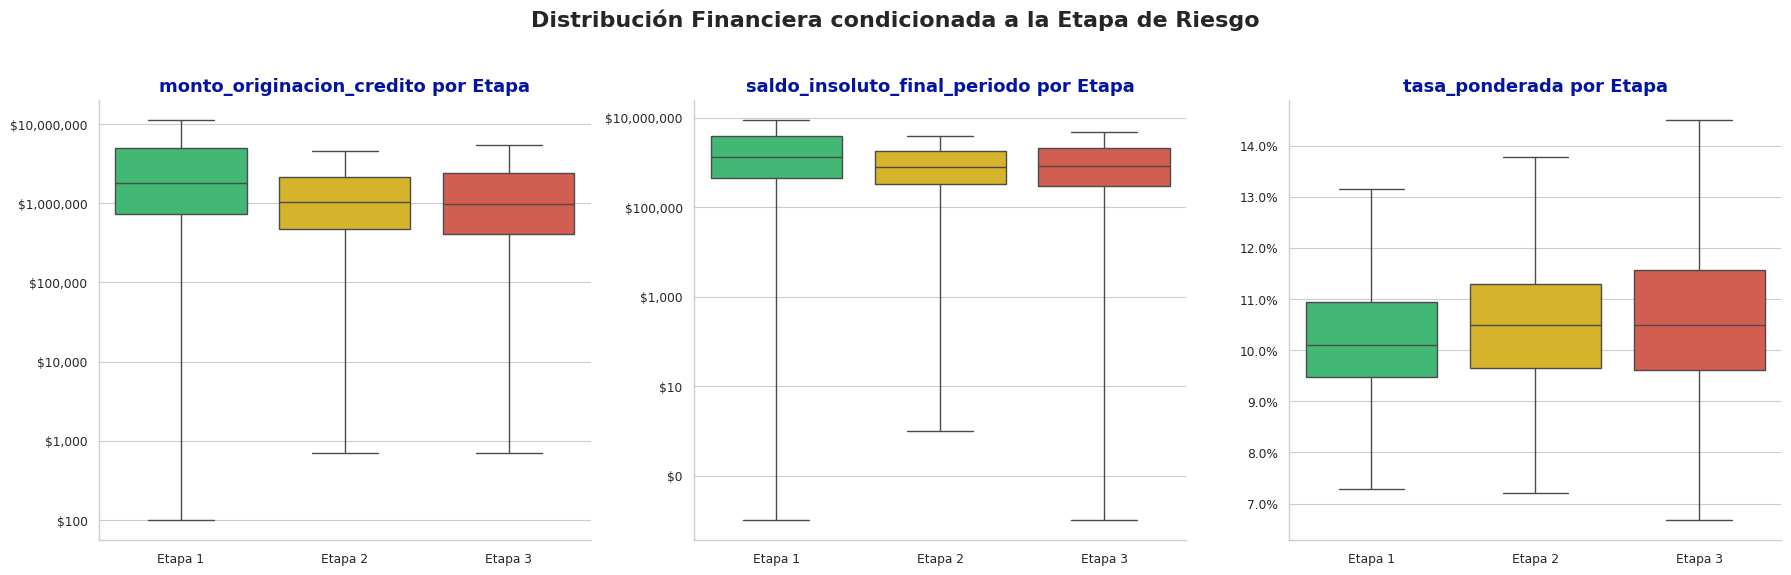

Medianas de las variables por Etapa de Riesgo:


,monto_originacion_credito,saldo_insoluto_final_periodo,tasa_ponderada
etapa,,,
Etapa 1,1788958.32,1286462.10,10.10
Etapa 2,1024969.07,779596.21,10.49
Etapa 3,993600.00,793519.76,10.50


In [16]:
print("=" * 60)
print("ANÁLISIS DE RIESGO: VARIABLES FINANCIERAS VS. ETAPA")
print("=" * 60)

# Variables financieras a evaluar
vars_financieras_riesgo = [
    'monto_originacion_credito', 
    'saldo_insoluto_final_periodo', 
    'tasa_ponderada'
]

# Orden lógico de las etapas para la gráfica
orden_etapas = ['Etapa 1', 'Etapa 2', 'Etapa 3']
paleta_riesgo = {"Etapa 1": "#2ecc71", "Etapa 2": "#f1c40f", "Etapa 3": "#e74c3c"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribución Financiera condicionada a la Etapa de Riesgo', fontsize=16, fontweight='bold')

for i, col in enumerate(vars_financieras_riesgo):
    ax = axes[i]
    
    # Filtramos valores mayores a cero si vamos a aplicar escala logarítmica
    datos_grafica = df_muestra[df_muestra[col] > 0] if col != 'tasa_ponderada' else df_muestra
    
    sns.boxplot(
        x='etapa', 
        y=col, 
        data=datos_grafica, 
        order=orden_etapas, 
        palette=paleta_riesgo,
        ax=ax,
        showfliers=False # OCULTAMOS LOS OUTLIERS EXTREMOS PARA VISUALIZAR MEJOR LAS CAJAS
    )
    
    ax.set_title(f'{col} por Etapa', fontsize=13, fontweight='bold', color='#03149E')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Formateo de ejes y escalas
    if col != 'tasa_ponderada':
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'${y:,.0f}'))
    else:
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=100))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
sns.despine()
plt.show()

# Imprimimos también las medianas exactas para respaldo cuantitativo
print("Medianas de las variables por Etapa de Riesgo:")
resumen_medianas = df_muestra.groupby('etapa')[vars_financieras_riesgo].median().reindex(orden_etapas)
display(resumen_medianas)

**Interpretación**: Las medianas de las variables continuas revelan lo siguiente:
* Primero, observamos que los créditos sanos (Etapa 1) tienen montos de originación significativamente mayores ($1,788,958 MXN) en comparación con la cartera en deterioro y vencida (alrededor de $1,000,000 MXN). Esto concuerda con lo que se descubrió en la variable segmento_vivienda: las propiedades de Interés Social (asociadas a montos menores) presentan mayores tasas de incumplimiento que el segmento Residencial. Además es lógico pensar, que para montos mayores de crédito, se requieran filtros más estrictos de aprobación, por lo qué es menos probable que estos créditos caigan en riesgo de impago.
* Por otro lado, la mediana de la tasa de interés sube paulatinamente conforme empeora el nivel de riesgo (del 10.10% en la Etapa 1 al 10.50% en la Etapa 3). Esto indica que los bancos logran identificar y penalizar perfiles ligeramente más riesgosos desde el momento de la originación asignándoles un costo de financiamiento más alto.

## 5.4. Visualización adicional: Variable temporal vs Variable Objetivo
El riesgo crediticio no es un fenómeno estático; está sujeto a los ciclos económicos, las políticas de tasas de interés de los bancos centrales y la inflación.
Analizaremos la variable `periodo` mediante una serie de tiempo. Nuestro objetivo es observar si la Tasa de Deterioro (la suma del porcentaje de Etapa 2 y Etapa 3) se ha mantenido constante a lo largo de los 25 meses registrados en el dataset, o si existe una tendencia al alza que indique un deterioro macroeconómico en la cartera de vivienda mexicana.

EVOLUCIÓN TEMPORAL DE LA CARTERA VENCIDA
Tendencia de deterioro (Primeros y últimos 3 meses):


etapa,Tasa de Deterioro (%)
periodo,
202404,18.28
202405,18.02
202406,18.18
202407,18.23
202408,18.10
202409,18.75
202410,18.61
202411,18.94
202412,18.55


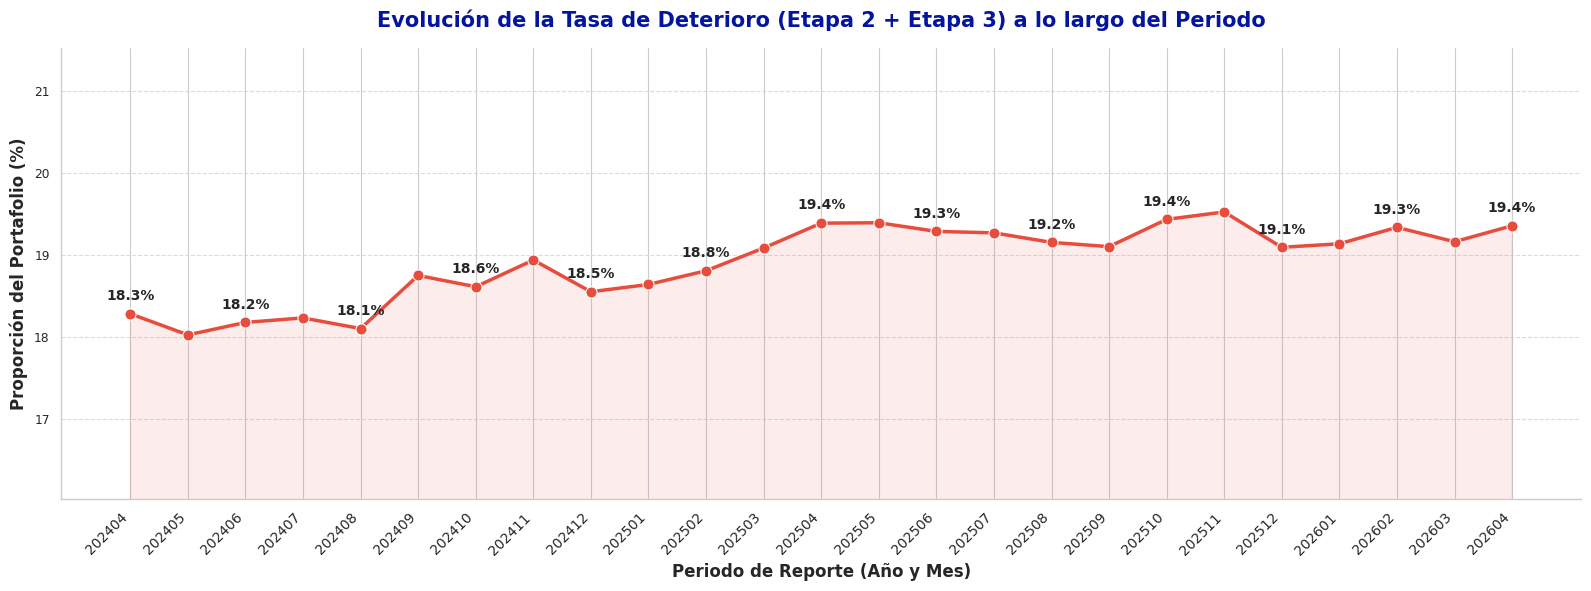

In [17]:
import matplotlib.dates as mdates

print("=" * 60)
print("EVOLUCIÓN TEMPORAL DE LA CARTERA VENCIDA")
print("=" * 60)

# 1. Preparación de los datos temporales
# Agrupamos por periodo y calculamos el porcentaje de cada etapa
df_tiempo = df_muestra.groupby('periodo')['etapa'].value_counts(normalize=True).unstack(fill_value=0) * 100

# Calculamos la Tasa de Deterioro Total (Etapa 2 + Etapa 3)
df_tiempo['Tasa de Deterioro (%)'] = df_tiempo.get('Etapa 2', 0) + df_tiempo.get('Etapa 3', 0)

# Aseguramos que el índice esté ordenado cronológicamente y lo convertimos a string para la gráfica
df_tiempo = df_tiempo.sort_index()
df_tiempo.index = df_tiempo.index.astype(str)

# Mostramos un extracto numérico para validar
print("Tendencia de deterioro (Primeros y últimos 3 meses):")
# display(pd.concat([df_tiempo[['Tasa de Deterioro (%)']].head(3), df_tiempo[['Tasa de Deterioro (%)']].tail(3)]).round(2))
display(df_tiempo[['Tasa de Deterioro (%)']].round(2)) # Mostramos todas las filas

# 2. Generación del Gráfico de Líneas (Serie de Tiempo)
plt.figure(figsize=(16, 6))

ax = sns.lineplot(
    x=df_tiempo.index, 
    y=df_tiempo['Tasa de Deterioro (%)'], 
    marker='o', 
    linewidth=2.5, 
    color='#e74c3c',
    markersize=8
)

# Rellenamos el área bajo la curva para darle mayor impacto visual
plt.fill_between(df_tiempo.index, df_tiempo['Tasa de Deterioro (%)'], color='#e74c3c', alpha=0.1)

plt.title('Evolución de la Tasa de Deterioro (Etapa 2 + Etapa 3) a lo largo del Periodo', fontsize=15, fontweight='bold', color='#03149E', pad=15)
plt.xlabel('Periodo de Reporte (Año y Mes)', fontsize=12, fontweight='bold')
plt.ylabel('Proporción del Portafolio (%)', fontsize=12, fontweight='bold')

# Rotamos las etiquetas del eje X para que no se superpongan
plt.xticks(rotation=45, ha='right', fontsize=10)

# Agregamos las etiquetas de valor a los puntos (mostrando 1 de cada 2 para no saturar)
for i, valor in enumerate(df_tiempo['Tasa de Deterioro (%)']):
    if i % 2 == 0 or i == len(df_tiempo)-1: # Mostrar el valor actual y el último
        ax.annotate(f'{valor:.1f}%', 
                    (df_tiempo.index[i], valor),
                    textcoords="offset points", 
                    xytext=(0,10), 
                    ha='center', 
                    fontsize=10, 
                    fontweight='bold')

# Ajustamos el límite inferior del eje Y para evitar que variaciones minúsculas parezcan gigantescas
plt.ylim(max(0, df_tiempo['Tasa de Deterioro (%)'].min() - 2), df_tiempo['Tasa de Deterioro (%)'].max() + 2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación**: Los datos revelan una tendencia de deterioro macroeconómico gradual pero sostenida en el portafolio hipotecario. En abril de 2024, la tasa de morosidad se ubicaba en 18.28%. A lo largo de los siguientes 24 meses, experimentó un incremento escalonado hasta alcanzar un pico de 19.52% a finales de 2025, estabilizándose alrededor del 19.36% para el cierre de la muestra en abril de 2026.

Este incremento absoluto de más de un punto porcentual (que en términos de cartera hipotecaria representa cientos de millones de pesos en riesgo) sugiere un entorno de estrés financiero prolongado para los prestatarios, posiblemente derivado de presiones inflacionarias que merman el poder adquisitivo. Esta variable temporal confirma que el riesgo no es un fenómeno estático y justifica la necesidad de recalibrar los modelos predictivos periódicamente.

# 6. Detección y Tratamiento de Valores Atípicos (Outliers)
Como observamos en nuestro análisis univariado, los valores máximos de variables como el `monto_originacion_credito` se alejan por miles de millones de pesos de la media poblacional. Para que los modelos predictivos y los algoritmos de agrupación (especialmente aquellos basados en distancias euclidianas como K-Means) no se vean distorsionados, es necesario cuantificar estos valores extremos y decidir una estrategia de tratamiento.

## 6.1. Rango Intercuartílico (IQR)
En particular, utilizaremos la medida del Rango Intercuartílico (IQR), para la detección de outliers:
$$
IQR = Q_3 - Q_1
$$
donde consideramos como atípicos cualquier observación que caiga fuera de los siguientes límites (bigotes):
* Límite Inferior: $Q_1 - 1.5 \times IQR$
* Límite Superior: $Q_3 + 1.5 \times IQR$
A continuación, calcularemos estos límites para nuestras variables numéricas, cuantificaremos la proporción de atípicos y generaremos gráficos de caja (boxplots).

DETECCIÓN DE ATÍPICOS (IQR)


,Variable,Q1,Q3,IQR,Lím. Superior,Total Atípicos,% Atípicos
0,monto_originacion_credito,650390.00,4200000.00,3549610.0,9524415.00,126588,12.66
1,valor_vivienda_originacion,1145000.00,6999000.00,5854000.0,15780000.00,126566,12.66
2,saldo_insoluto_final_periodo,415318.73,3315308.54,2899989.8,7665293.24,125722,12.57
3,tasa_ponderada,9.50,11.00,1.5,13.25,65797,6.58


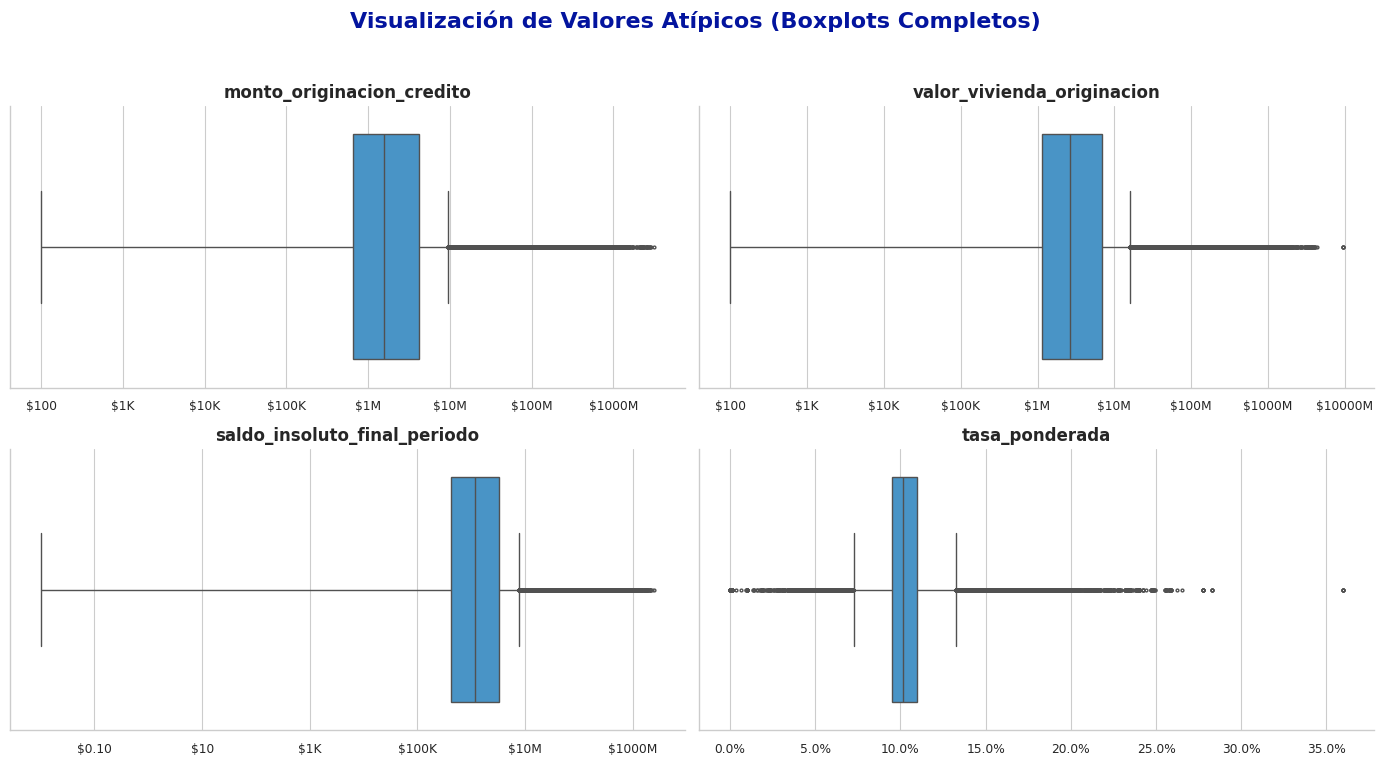

In [18]:
print("=" * 60)
print("DETECCIÓN DE ATÍPICOS (IQR)")
print("=" * 60)

# Variables numéricas a analizar
vars_atipicos = [
    'monto_originacion_credito', 
    'valor_vivienda_originacion', 
    'saldo_insoluto_final_periodo', 
    'tasa_ponderada'
]

# Diccionario para almacenar los resultados y decidir estrategias
resumen_outliers = []

for col in vars_atipicos:
    # Cálculo de cuartiles e IQR
    Q1 = df_muestra[col].quantile(0.25)
    Q3 = df_muestra[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Conteo de outliers
    outliers_inferiores = df_muestra[df_muestra[col] < limite_inferior].shape[0]
    outliers_superiores = df_muestra[df_muestra[col] > limite_superior].shape[0]
    total_outliers = outliers_inferiores + outliers_superiores
    porcentaje = (total_outliers / len(df_muestra)) * 100
    
    resumen_outliers.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lím. Superior': limite_superior,
        'Total Atípicos': total_outliers,
        '% Atípicos': porcentaje
    })

# Mostramos la tabla resumen
df_outliers = pd.DataFrame(resumen_outliers)
display(df_outliers.round(2))

# Visualización mediante Boxplots clásicos
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Visualización de Valores Atípicos (Boxplots Completos)', fontsize=16, fontweight='bold', color='#03149E')
axes = axes.flatten()

for i, col in enumerate(vars_atipicos):
    # Usamos escala logarítmica en los montos monetarios para que el boxplot sea legible
    # Filtrando temporalmente el cero estricto
    datos = df_muestra[df_muestra[col] > 0] if col != 'tasa_ponderada' else df_muestra
    
    sns.boxplot(x=datos[col], ax=axes[i], color='#3498db', fliersize=2)
    
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    
    if col != 'tasa_ponderada':
        axes[i].set_xscale('log')
        axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(formato_pesos_log))
    else:
        axes[i].xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
sns.despine()
plt.show()

**Interpretación**: Los resultados del rango intercuartílico revelan un volumen masivo de valores atípicos. Aproximadamente el 12.6% de la muestra en las variables monetarias (cerca de 126,000 cohortes) excede el límite superior matemático. En la tasa ponderada, los atípicos representan el 6.58%, concentrados principalmente en el extremo superior (tasas mayores al 13.25%).

## 6.2. Estrategia de Tratamiento
Un valor atípico puede representar un error de medición o captura (ruido) que debe ser eliminado. Sin embargo, también pueden ser observaciones válidas con valores extremos. En este contexto del riesgo financiero, un crédito de $15 millones de pesos o un portafolio de $50 millones no es un error de base de datos; es una realidad comercial de alto valor para el banco (grandes proyectos de desarollo o financiamiento).

**Decisión metodológica:**
Eliminar el 12% de nuestra base de datos destruiría la representatividad estadística del portafolio y sesgaría nuestro modelo, impidiéndole aprender el comportamiento de los créditos de mayor volumen. Por lo tanto, no eliminaremos ninguna fila.

Dado que implementaremos modelos de aprendizaje supervisado (potencialmente sensibles a la escala, como redes neuronales) y algoritmos de clustering basados en distancias, dejar estos valores crudos distorsionaría drásticamente los cálculos matemáticos. La estrategia será aplicar una transformación en la futura fase de pre-procesamiento, optando por escaladores robustos (como RobustScaler, que utiliza la mediana y el IQR en lugar de la media) o conservando la transformación logarítmica que ya comprobamos que estabiliza la varianza de los montos monetarios.

# 8. Reducción de Dimensionalidad
Con el EDA concluido, poseemos un entendimiento profundo de la calidad, distribución y relaciones de nuestras variables. Finalizamos con la fase faltante de preprocesamiento que iniciamos en la sección 3, la cual es optimizar nuestro espacio de características, combatiendo la "maldición de la dimensionalidad".

## 8.1. PCA vs. Selección de Características
El Análisis de Componentes Principales (PCA) es una técnica común para la reducción de dimensionalidad. Matemáticamente, el PCA busca proyectar los datos originales en un nuevo sistema de coordenadas ortogonales de menor dimensión de tal forma que se maximice la varianza retenida. Esto se logra calculando la matriz de covarianza de los datos estandarizados y obteniendo sus eigenvalores y eigenvectores (frecuentemente optimizado computacionalmente a través de la Descomposición en Valores Singulares o SVD). Sin embargo, a pesar de su elegancia matemática, el PCA presenta limitaciones que lo hacen incompatible con los objetivos de este proyecto financiero:
* Pérdida de interpretabilidad: En el dataset financiero, un modelo de asignación de riesgo debe ser enteramente interpretable y explicable. Si un crédito es clasificado con alta probabilidad de deterioro, debemos poder justificarlo con variables reales (ej. "por pertenecer al segmento de Interés Social con ingresos menores a 10k MXN"). El PCA transforma las variables originales en combinaciones lineales abstractas; usar un componente principal como predictor impide entender la trazabilidad para las decisiones de negocio.
* Naturaleza de los datos: El PCA asume implícitamente que los datos son variables numéricas continuas. Nuestro dataset es mayormente categórico (estado, género, moneda, segmento). Intentar aplicar PCA sobre variables categóricas distorsionaria la estructura geométrica de las distancias.
* Otras alternativas de reducción no lineal como t-SNE o UMAP son útiles para proyectar clusters y descubrir geometrías complejas, pero sufren de la misma falta de interpretabilidad.

Por los motivos expuestos, descartaremos las técnicas de proyección multivariada y optaremos por una Selección de Características (Feature Selection) basada en el conocimiento de dominio y filtros estadísticos obtenidos durante nuestro EDA:
En la siguiente sección, aplicaremos los siguientes criterios de exclusión:
* Colinealidad: Descartaremos las métricas financieras redundantes detectadas en el Heatmap.
* Redundancia: Unificaremos o descartaremos variables demográficas que describen el mismo fenómeno poblacional.
* Alta Cardinalidad: Eliminaremos variables que fungen como identificadores excesivamente granulares y que demostraron no tener capacidad de generalización.

## 8.2. Estrategia para la Selección de Características
Con base en el Análisis Exploratorio de Datos, aplicaremos un filtrado para construir el vector de características definitivo para reducir la dimensionalidad, optimizar el costo y priorizar la Probabilidad de Incumplimiento o Tasa de Deterioro.

### Eliminación por Alta Colinealidad (Correlación de Pearson)
La matriz de correlación (Sección 5.1) demostró que las variables de masa monetaria exhiben una relación lineal demasiado alta ($|r| > 0.94$). Mantener estas variables viola el supuesto de independencia y, aunque arquitecturas complejas como las Redes Neuronales pueden tolerar cierta colinealidad, la redundancia inyecta ruido innecesario a los gradientes y aumenta exponencialmente el riesgo de sobreajuste (overfitting).

Más allá de la correlación matemática, la elección de qué variable conservar responde al objetivo del proyecto. Nuestro enfoque no es un Modelo de Admisión o *Application Scoring* (donde el objetivo es decidir si se debe aprobar un crédito o no), sino un está enfocado a un Modelo de Comportamiento o *Behavioral Scoring* (donde el objetivo es monitorear la salud de una cartera activa y el comportamiento del cliente). De esta forma `monto_originacion_credito` representa un dato histórico y estático, mientras que el `saldo_insoluto_final_periodo` representa la deuda viva y actual. Esta es la métrica más útil de riesgo al momento de evaluar la etapa actual.

**Decisión**: Conservaremos únicamente el `saldo_insoluto_final_periodo` como indicador de exposición al momento del impago (EAD - Exposure at Default) y la `tasa_ponderada` como indicador del costo del dinero.
**Variables eliminadas**:
* `monto_originacion_credito`
* `valor_vivienda_originacion`
* `tasa_interes_por_saldo_insoluto_final_periodo`

### Eliminación por Redundancia Categórica
Durante la Sección 4.3, evidenciamos que las variables `tipo_acreditado` y `sector_laboral` poseen una distribución de frecuencias idéntica. Introducir ambas al modelo aumentaría el coste computacional innecesariamente.
**Decisión**: Conservaremos `sector_laboral` por su mayor claridad semántica.
**Variables eliminadas**:
* `tipo_acreditado`

### Eliminación por Alta Cardinalidad y Ruido
El espacio de características experimenta una explosión matemática cuando variables con cientos de categorías son transformadas mediante codificación One-Hot. La variable clave_producto_hipotecario posee 471 categorías con una bajísima concentración (Sección 4.4). Incluirla generaría una matriz dispersa masiva, ralentizando el entrenamiento y aportando un nulo poder de generalización fuera de la institución emisora. Lo mismo ocurre con variables puramente administrativas. Además para los efectos de este proyecto, la variable temporal `periodo` también será excluida del modelo, ya que buscamos generalizar el riesgo independientemente del mes de extracción.
**Decisión**: Descartar variables granulares no predictivas.
**Variables eliminadas**: 
* `clave_producto_hipotecario`
* `institucion` 
* `sector`
* `periodo`

### Vector de características final
Tras este profundo análisis, nuestro modelo ingresará con un dataset altamente limpio, interpretable y más compacto, compuesto por las siguientes dimensiones:
|-| columna |
|-|-|
|0| `intervalo_edades` |
|1| `intervalo_ingreso_acreditado` |
|2| `sector_laboral` |
|3| `estado` |
|4| `destino_credito` |
|5| `segmento_vivienda` |
|6| `moneda` |
|7| `saldo_insoluto_final_periodo` |
|8| `tasa_ponderada` |
|9| `etapa` |

Las variables serán ordenadas jerárquicamente: primero las dimensiones demográficas y socioeconómicas, seguidas por las de la naturaleza del inmueble, luego las métricas financieras y, finalmente, nuestra variable objetivo.

Este conjunto de datos final, será exportado en su formato interpretable. Otras transformaciones de datos como, las codificaciones y normalización de variables se diferirán a la fase de modelado.

In [20]:
import os

print("=" * 60)
print("CONSOLIDACIÓN Y EXPORTACIÓN DEL DATASET FINAL")
print("=" * 60)

# 1. Definición del orden estricto de las características
columnas_finales = [
    'intervalo_edades', 
    'intervalo_ingreso_acreditado', 
    'sector_laboral', 
    'estado', 
    'destino_credito', 
    'segmento_vivienda', 
    'moneda', 
    'saldo_insoluto_final_periodo', 
    'tasa_ponderada', 
    'etapa'
]

# 2. Filtrado y reordenamiento
df_final = df_muestra[columnas_finales].copy()

# 3. Verificación de la estructura final
print(f"Dimensiones del dataset final: {df_final.shape[0]:,} filas x {df_final.shape[1]} columnas.\n")
print("Vista previa del dataset analítico:")
display(df_final.head())

# 4. Exportación a disco
ruta_exportacion = '../data/Datos_Procesados'

# Crear el directorio si no existe
if not os.path.exists(ruta_exportacion):
    os.makedirs(ruta_exportacion)
    print(f"\nDirectorio creado: {ruta_exportacion}")

archivo_salida = os.path.join(ruta_exportacion, 'dataset_hipotecario_limpio.csv')

# Guardamos como CSV sin el índice para no generar una columna extra basura
df_final.to_csv(archivo_salida, index=False)
print(f"\n[ÉXITO] Dataset exportado exitosamente en: {archivo_salida}")

CONSOLIDACIÓN Y EXPORTACIÓN DEL DATASET FINAL
Dimensiones del dataset final: 1,000,000 filas x 10 columnas.

Vista previa del dataset analítico:


,intervalo_edades,intervalo_ingreso_acreditado,sector_laboral,estado,destino_credito,segmento_vivienda,moneda,saldo_insoluto_final_periodo,tasa_ponderada,etapa
1227318,36-45,"(10,001 - 20,000)",Sector privado,YUCATÁN,Adquisición de Vivienda Nueva,Media o Residencial,Moneda Nacional (Pesos),512217.49,9.62,Etapa 1
4113476,Más de 65,"(40,001 - 80,000)",Sector privado,HIDALGO,Adquisición de Vivienda Nueva,Media o Residencial,Moneda Nacional (Pesos),1637998.59,9.68,Etapa 1
1614363,46-55,"(20,001 - 40,000)",Sector privado,BAJA CALIFORNIA SUR,Adquisición de Vivienda Usada,Media o Residencial,Moneda Nacional (Pesos),17353.42,10.52,Etapa 1
6116493,46-55,"(10,001 - 20,000)",Sector privado,NUEVO LEÓN,Adquisición de Vivienda Usada,Media o Residencial,Moneda Nacional (Pesos),1412758.94,10.34,Etapa 1
2440109,56-65,"(40,001 - 80,000)",Sector privado,GUANAJUATO,Adquisición de Vivienda Usada,Media o Residencial,Moneda Nacional (Pesos),5963299.75,9.79,Etapa 1



[ÉXITO] Dataset exportado exitosamente en: ../data/Datos_Procesados/dataset_hipotecario_limpio.csv
